# 06 - Visualisasi Perbandingan Konfigurasi RAG

Notebook ini memvisualisasikan hasil evaluasi semua konfigurasi RAG yang sudah di-run.
Tujuan: menghasilkan gambar-gambar untuk skripsi (Bab VI Evaluasi) dengan format yang
konsisten dan publication-ready.

## Scope Data (Hybrid Retrieval)

Semua konfigurasi memakai **Hybrid Retrieval** (BM25 + Dense via RRF) sebagai retriever dasar.

### 8 Konfigurasi Utama (Llama vs OpenAI)

| Teknik    | Llama 3.3 70B  | OpenAI GPT-4.1-mini |
|-----------|:---:|:---:|
| Baseline  | `baseline_llama`  | `baseline_openai`  |
| QR        | `qr_llama`        | `qr_openai`        |
| CR        | `cr_llama`        | `cr_openai`        |
| QR + CR   | `qr_cr_llama`     | `qr_cr_openai`     |

### 1 Konfigurasi Pilot (Multi-Provider Validation)

- **Claude Haiku 4.5 Baseline** (`baseline_claude`) - validasi cross-provider

**Total: 9 konfigurasi** dengan 4 metrik RAGAS lengkap (faithfulness, context_recall, answer_relevancy, context_precision).

## Output

Setiap visualisasi disimpan sebagai PNG di `figures/` untuk include di LaTeX:
```latex
\includegraphics[width=\textwidth]{figures/A_accuracy_comparison.png}
```

## Section F (di bawah)

Section F membandingkan **OpenAI BM25 vs Hybrid** sebagai analisis tambahan tentang
dampak upgrade retriever (BM25 sparse vs Hybrid dense+sparse).

## 0. Setup & Data Loading

In [1]:
import json
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
import seaborn as sns

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Serif'  # mirip Times New Roman di LaTeX
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['savefig.bbox'] = 'tight'

# Setup folders
RESULTS_DIR = Path('../results')
BM25_DIR = RESULTS_DIR / 'BM25'
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

print(f'Results dir: {RESULTS_DIR.resolve()}')
print(f'BM25 archive: {BM25_DIR.resolve()}')
print(f'Figures output: {FIGURES_DIR.resolve()}')

Results dir: C:\Users\Ricky Wijaya\Documents\STI\Semester 8\TA\Code TA\results
BM25 archive: C:\Users\Ricky Wijaya\Documents\STI\Semester 8\TA\Code TA\results\BM25
Figures output: C:\Users\Ricky Wijaya\Documents\STI\Semester 8\TA\Code TA\notebooks\figures


In [2]:
def load_config(phase1_path, phase2_path):
    """Load Phase 1 + Phase 2 data, return dict of metrics."""
    with open(phase1_path, encoding='utf-8') as f:
        p1 = json.load(f)['results']
    try:
        with open(phase2_path, encoding='utf-8') as f:
            p2 = json.load(f)['results']
    except FileNotFoundError:
        p2 = []

    n = len(p1)
    correct = sum(r['is_correct'] for r in p1)

    # Per-label
    per_label = {}
    for lbl in ['yes', 'no', 'maybe']:
        sub = [r for r in p1 if r['ground_truth'] == lbl]
        per_label[lbl] = {
            'correct': sum(r['is_correct'] for r in sub),
            'total': len(sub),
            'accuracy': sum(r['is_correct'] for r in sub) / len(sub) if sub else 0
        }

    # Prediction distribution
    pred_dist = {'yes': 0, 'no': 0, 'maybe': 0}
    for r in p1:
        pred_dist[r['predicted_label']] += 1

    # Metrics
    metrics = {}
    for m in ['faithfulness', 'context_recall', 'answer_relevancy', 'context_precision']:
        vals = [r[m] for r in p2 if m in r]
        metrics[m] = sum(vals) / len(vals) if vals else None

    return {
        'n': n,
        'correct': correct,
        'accuracy': correct / n if n else 0,
        'per_label': per_label,
        'pred_dist': pred_dist,
        **metrics,
    }


# ============================================================
# Load 9 Hybrid configurations
# - 4 Llama 3.3 70B (Baseline, QR, CR, QR+CR)
# - 4 OpenAI GPT-4.1-mini (Baseline, QR, CR, QR+CR)
# - 1 Claude Haiku 4.5 Baseline (pilot multi-provider)
# ============================================================
CONFIGS = OrderedDict([
    # key: (phase1_file, phase2_file, model, retrieval, technique)
    # --- 4 Hybrid Llama ---
    ('BL_Llama',    (RESULTS_DIR / 'baseline_llama_phase1_answers.json',
                      RESULTS_DIR / 'baseline_llama_phase2_custom.json',
                      'Llama 3.3 70B', 'Hybrid', 'Baseline')),
    ('QR_Llama',    (RESULTS_DIR / 'qr_llama_phase1_answers.json',
                      RESULTS_DIR / 'qr_llama_phase2_custom.json',
                      'Llama 3.3 70B', 'Hybrid', 'QR')),
    ('CR_Llama',    (RESULTS_DIR / 'cr_llama_phase1_answers.json',
                      RESULTS_DIR / 'cr_llama_phase2_custom.json',
                      'Llama 3.3 70B', 'Hybrid', 'CR')),
    ('QRCR_Llama',  (RESULTS_DIR / 'qr_cr_llama_phase1_answers.json',
                      RESULTS_DIR / 'qr_cr_llama_phase2_custom.json',
                      'Llama 3.3 70B', 'Hybrid', 'QR+CR')),
    # --- 4 Hybrid OpenAI ---
    ('BL_OpenAI',   (RESULTS_DIR / 'baseline_openai_phase1_answers.json',
                      RESULTS_DIR / 'baseline_openai_phase2_custom.json',
                      'GPT-4.1-mini', 'Hybrid', 'Baseline')),
    ('QR_OpenAI',   (RESULTS_DIR / 'qr_openai_phase1_answers.json',
                      RESULTS_DIR / 'qr_openai_phase2_custom.json',
                      'GPT-4.1-mini', 'Hybrid', 'QR')),
    ('CR_OpenAI',   (RESULTS_DIR / 'cr_openai_phase1_answers.json',
                      RESULTS_DIR / 'cr_openai_phase2_custom.json',
                      'GPT-4.1-mini', 'Hybrid', 'CR')),
    ('QRCR_OpenAI', (RESULTS_DIR / 'qr_cr_openai_phase1_answers.json',
                      RESULTS_DIR / 'qr_cr_openai_phase2_custom.json',
                      'GPT-4.1-mini', 'Hybrid', 'QR+CR')),
    # --- Pilot multi-provider: Claude Haiku 4.5 ---
    ('BL_Claude',   (RESULTS_DIR / 'baseline_claude_phase1_answers.json',
                      RESULTS_DIR / 'baseline_claude_phase2_custom.json',
                      'Claude Haiku 4.5', 'Hybrid', 'Baseline')),
])


records = []
for key, (p1, p2, model, retrieval, technique) in CONFIGS.items():
    try:
        data = load_config(p1, p2)
        records.append({
            'key': key,
            'model': model,
            'retrieval': retrieval,
            'technique': technique,
            **data
        })
    except Exception as e:
        print(f'  SKIP {key}: {e}')

df = pd.DataFrame(records)

# Flatten per_label for easier use
for lbl in ['yes', 'no', 'maybe']:
    df[f'{lbl}_correct'] = df['per_label'].apply(lambda x: x[lbl]['correct'])
    df[f'{lbl}_total']   = df['per_label'].apply(lambda x: x[lbl]['total'])
    df[f'{lbl}_accuracy']= df['per_label'].apply(lambda x: x[lbl]['accuracy'])

# Sort: Llama first, then OpenAI, then Claude; technique order: BL, QR, CR, QR+CR
model_order = {'Llama 3.3 70B': 0, 'GPT-4.1-mini': 1, 'Claude Haiku 4.5': 2}
tech_order  = {'Baseline': 0, 'QR': 1, 'CR': 2, 'QR+CR': 3}
df['_m'] = df['model'].map(model_order)
df['_t'] = df['technique'].map(tech_order)
df = df.sort_values(['_m', '_t']).drop(columns=['_m', '_t']).reset_index(drop=True)

print(f'Loaded {len(df)} konfigurasi')
df[['key', 'model', 'technique', 'accuracy',
    'faithfulness', 'context_recall', 'answer_relevancy', 'context_precision']].round(4)

Loaded 9 konfigurasi


,key,model,technique,accuracy,faithfulness,context_recall,answer_relevancy,context_precision
0,BL_Llama,Llama 3.3 70B,Baseline,0.694,0.8209,0.7259,0.9509,0.9098
1,QR_Llama,Llama 3.3 70B,QR,0.682,0.8093,0.7235,0.9475,0.9111
2,CR_Llama,Llama 3.3 70B,CR,0.708,0.8251,0.7293,0.9597,0.9373
3,QRCR_Llama,Llama 3.3 70B,QR+CR,0.710,0.8112,0.7532,0.9630,0.9354
4,BL_OpenAI,GPT-4.1-mini,Baseline,0.692,NaN,NaN,NaN,NaN
5,QR_OpenAI,GPT-4.1-mini,QR,0.708,NaN,NaN,NaN,NaN
6,CR_OpenAI,GPT-4.1-mini,CR,0.698,NaN,NaN,NaN,NaN
7,QRCR_OpenAI,GPT-4.1-mini,QR+CR,0.700,NaN,NaN,NaN,NaN
8,BL_Claude,Claude Haiku 4.5,Baseline,0.654,0.5991,0.5407,0.7090,0.8562


## A. Perbandingan Label Accuracy

**Insight utama:** konfigurasi mana yang menghasilkan accuracy tertinggi?

Bar chart ini membandingkan label accuracy semua konfigurasi, dikelompokkan per model.

NameError: name 'best_y' is not defined

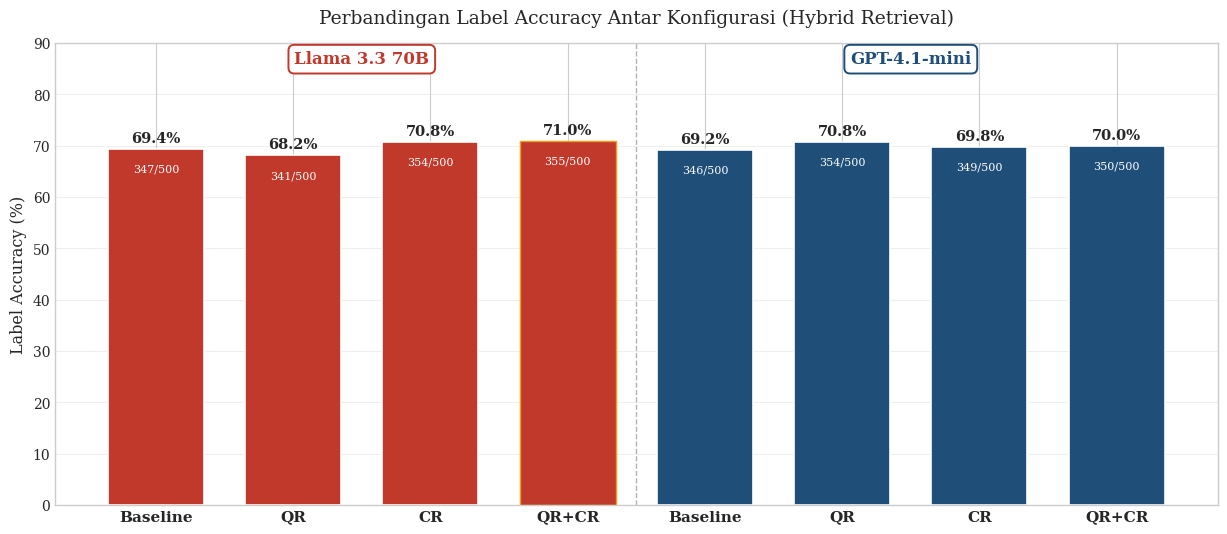

In [3]:
fig, ax = plt.subplots(figsize=(15, 6))

# Warna berdasarkan model (Hybrid retrieval). Claude di-exclude karena pilot test
# (dibahas terpisah di subbab khusus, tidak masuk perbandingan utama).
color_map = {
    'Llama 3.3 70B': '#c0392b',  # merah
    'GPT-4.1-mini':  '#1f4e79',  # biru tua
}

# Filter: hanya 8 konfig utama (Llama + OpenAI), Claude di-exclude
df_plot = df[df['model'].isin(color_map.keys())].copy().reset_index(drop=True)

# Label x-axis: technique saja (lebih ringkas; group model di-anotasi terpisah)
df_plot['x_label'] = df_plot['technique']
df_plot['color']   = df_plot['model'].map(color_map)

x_pos = np.arange(len(df_plot))
bars = ax.bar(x_pos, df_plot['accuracy'] * 100, color=df_plot['color'],
              edgecolor='white', linewidth=1.2, width=0.7)

# Annotate nilai di setiap bar
for bar, acc, n_correct, n_total in zip(bars, df_plot['accuracy'],
                                         df_plot['correct'], df_plot['n']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.7,
            f'{acc*100:.1f}%', ha='center', va='bottom',
            fontsize=10.5, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width()/2, height - 3,
            f'{n_correct}/{n_total}', ha='center', va='top',
            fontsize=8, color='white')

ax.set_xticks(x_pos)
ax.set_xticklabels(df_plot['x_label'], fontsize=11, fontweight='bold')
ax.set_ylabel('Label Accuracy (%)', fontsize=11.5)
ax.set_title('Perbandingan Label Accuracy Antar Konfigurasi (Hybrid Retrieval)',
             fontsize=13.5, pad=14)
ax.set_ylim(0, 90)  # headroom untuk anotasi Terbaik dan label group
ax.grid(axis='y', alpha=0.3)

# Pemisah vertikal antar group model
n_llama  = (df_plot['model'] == 'Llama 3.3 70B').sum()
n_openai = (df_plot['model'] == 'GPT-4.1-mini').sum()
ax.axvline(x=n_llama - 0.5, color='gray', linestyle='--', alpha=0.6, linewidth=1)

# Group label di atas bar (sebagai pengganti legenda yang sebelumnya nabrak)
group_y = 86
ax.text((n_llama - 1) / 2, group_y, 'Llama 3.3 70B',
        ha='center', fontsize=12, fontweight='bold', color='#c0392b',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                  edgecolor='#c0392b', linewidth=1.4))
ax.text(n_llama + (n_openai - 1) / 2, group_y, 'GPT-4.1-mini',
        ha='center', fontsize=12, fontweight='bold', color='#1f4e79',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                  edgecolor='#1f4e79', linewidth=1.4))

# Highlight bar TERBAIK dengan border emas tebal
best_idx = df_plot['accuracy'].idxmax()
best_row = df_plot.loc[best_idx]
# best_y   = best_row['accuracy'] * 100
bars[best_idx].set_edgecolor('#f39c12')
bars[best_idx].set_linewidth(1.0)

# Anotasi TERBAIK: kotak emas dengan bintang (mathtext) dan panah
ax.annotate(r'$\bigstar$ TERBAIK',
            xy=(best_idx, best_y + 0.8),
            xytext=(best_idx, best_y + 9),
            ha='center', fontsize=11.5, fontweight='bold', color='#b9770e',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#fef5e7',
                      edgecolor='#f39c12', linewidth=1.8))

# Bersihkan spines kanan dan atas untuk tampilan lebih rapi
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'A_accuracy_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\n[Saved] {FIGURES_DIR}/A_accuracy_comparison.png')
print(f'\nKonfigurasi terbaik: {best_row["technique"]} {best_row["model"]} = {best_row["accuracy"]*100:.1f}%')


## B. Heatmap 4 Metrik RAGAS

**Insight utama:** di dimensi mana setiap konfigurasi unggul?

Heatmap ini menampilkan keempat metrik RAGAS (Faithfulness, Context Recall, Answer Relevancy,
Context Precision) untuk setiap konfigurasi. Warna semakin hijau = semakin baik.

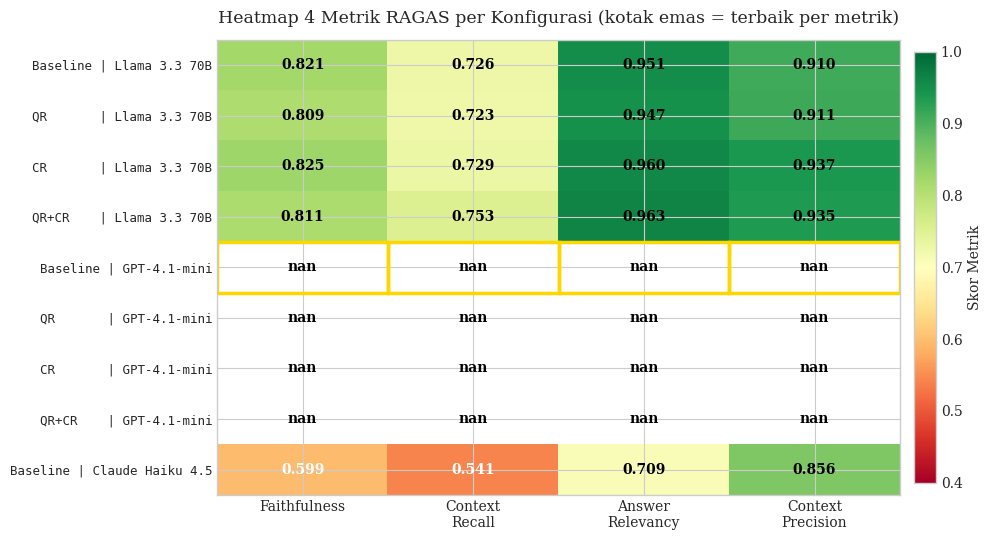


[Saved] figures/B_ragas_heatmap.png


In [4]:
# Prepare heatmap data
metrics_cols = ['faithfulness', 'context_recall', 'answer_relevancy', 'context_precision']
metric_labels = ['Faithfulness', 'Context\nRecall', 'Answer\nRelevancy', 'Context\nPrecision']

df_heat = df.copy()
df_heat['row_label'] = df_heat.apply(
    lambda r: f"{r['technique']:<8} | {r['model']}", axis=1
)

heat_data = df_heat[metrics_cols].values
row_labels = df_heat['row_label'].tolist()

fig, ax = plt.subplots(figsize=(10, 5.5))

im = ax.imshow(heat_data, cmap='RdYlGn', vmin=0.4, vmax=1.0, aspect='auto')

# Annotate cells
for i in range(heat_data.shape[0]):
    for j in range(heat_data.shape[1]):
        val = heat_data[i, j]
        text_color = 'white' if val < 0.65 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=10, fontweight='bold', color=text_color)

# Highlight best per kolom
for j in range(heat_data.shape[1]):
    best_i = np.argmax(heat_data[:, j])
    ax.add_patch(plt.Rectangle((j-0.5, best_i-0.5), 1, 1, fill=False,
                                edgecolor='gold', lw=2.5))

ax.set_xticks(np.arange(len(metric_labels)))
ax.set_xticklabels(metric_labels, fontsize=10)
ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=9, family='monospace')
ax.set_title('Heatmap 4 Metrik RAGAS per Konfigurasi (kotak emas = terbaik per metrik)',
             fontsize=12.5, pad=12)

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Skor Metrik', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'B_ragas_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\n[Saved] {FIGURES_DIR}/B_ragas_heatmap.png')

## C. Dampak Teknik Mitigasi (Delta vs Baseline)

**Insight utama:** apakah teknik mitigasi membantu, merusak, atau netral?

Bar chart ini menunjukkan **selisih accuracy** setiap teknik dibandingkan Baseline
untuk model yang sama. Hijau = membantu, merah = merusak.

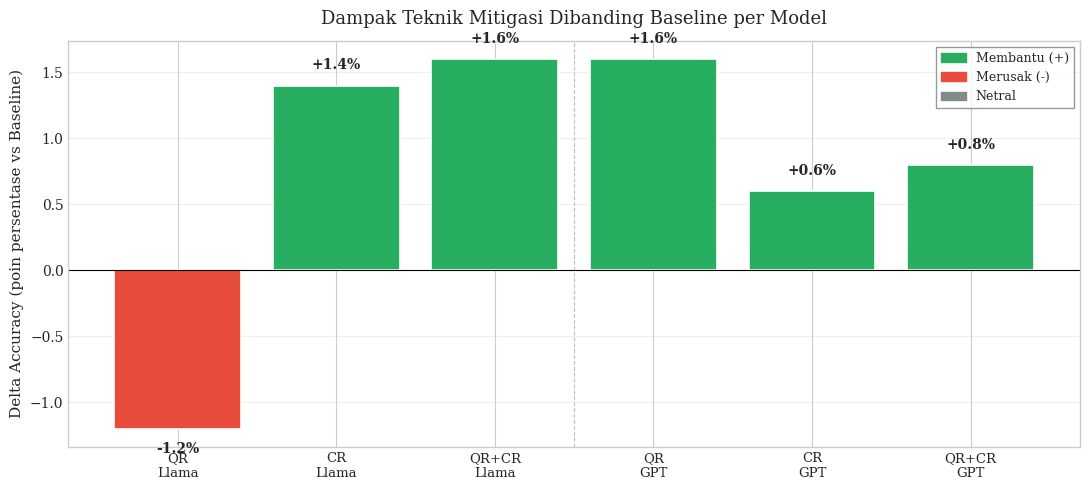


[Saved] figures/C_delta_vs_baseline.png

Delta per config:
        key  accuracy  baseline_acc  delta
   QR_Llama     0.682         0.694   -1.2
   CR_Llama     0.708         0.694    1.4
 QRCR_Llama     0.710         0.694    1.6
  QR_OpenAI     0.708         0.692    1.6
  CR_OpenAI     0.698         0.692    0.6
QRCR_OpenAI     0.700         0.692    0.8


In [5]:
# Compute delta vs baseline per model (semua Hybrid)
baselines = df[df['technique'] == 'Baseline'].set_index('model')['accuracy'].to_dict()

df_delta = df[df['technique'] != 'Baseline'].copy()
df_delta['baseline_acc'] = df_delta['model'].map(baselines)
df_delta['delta'] = (df_delta['accuracy'] - df_delta['baseline_acc']) * 100
df_delta = df_delta.dropna(subset=['baseline_acc'])

# Sort: Llama first, then OpenAI; technique order BL/QR/CR/QR+CR
model_order = {'Llama 3.3 70B': 0, 'GPT-4.1-mini': 1, 'Claude Haiku 4.5': 2}
tech_order = {'QR': 0, 'CR': 1, 'QR+CR': 2}
df_delta['_m'] = df_delta['model'].map(model_order)
df_delta['_t'] = df_delta['technique'].map(tech_order)
df_delta = df_delta.sort_values(['_m', '_t']).reset_index(drop=True)

df_delta['x_label'] = df_delta.apply(
    lambda r: f"{r['technique']}\n{r['model'].replace('Llama 3.3 70B', 'Llama').replace('GPT-4.1-mini', 'GPT')}",
    axis=1
)

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#27ae60' if d > 0 else ('#7f8c8d' if abs(d) < 0.05 else '#e74c3c') for d in df_delta['delta']]

x_pos = np.arange(len(df_delta))
bars = ax.bar(x_pos, df_delta['delta'], color=colors, edgecolor='white', linewidth=1.2)

# Annotate
for bar, delta in zip(bars, df_delta['delta']):
    h = bar.get_height()
    if h >= 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.1,
                f'+{delta:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
    else:
        ax.text(bar.get_x() + bar.get_width()/2, h - 0.1,
                f'{delta:.1f}%', ha='center', va='top', fontweight='bold', fontsize=10)

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')

# Vertical separator antar model group
n_llama_tech = (df_delta['model'] == 'Llama 3.3 70B').sum()
ax.axvline(x=n_llama_tech - 0.5, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)

ax.set_xticks(x_pos)
ax.set_xticklabels(df_delta['x_label'], fontsize=9.5)
ax.set_ylabel('Delta Accuracy (poin persentase vs Baseline)', fontsize=11)
ax.set_title('Dampak Teknik Mitigasi Dibanding Baseline per Model',
             fontsize=13, pad=12)
ax.grid(axis='y', alpha=0.3)

# Legend
legend_elements = [
    mpatches.Patch(color='#27ae60', label='Membantu (+)'),
    mpatches.Patch(color='#e74c3c', label='Merusak (-)'),
    mpatches.Patch(color='#7f8c8d', label='Netral'),
]
ax.legend(handles=legend_elements, loc='best', frameon=True, fancybox=False, edgecolor='gray')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'C_delta_vs_baseline.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\n[Saved] {FIGURES_DIR}/C_delta_vs_baseline.png')
print(f'\nDelta per config:')
print(df_delta[['key', 'accuracy', 'baseline_acc', 'delta']].round(3).to_string(index=False))

## D. Akurasi Per-Label (yes / no / maybe)

**Insight utama:** bagaimana pola bias prediksi antar konfigurasi?

Bar chart ini menunjukkan akurasi untuk setiap label, mengungkap apakah model bias ke
salah satu kategori. Ground truth distribution: `yes=275 (55%), no=159 (32%), maybe=66 (13%)`.

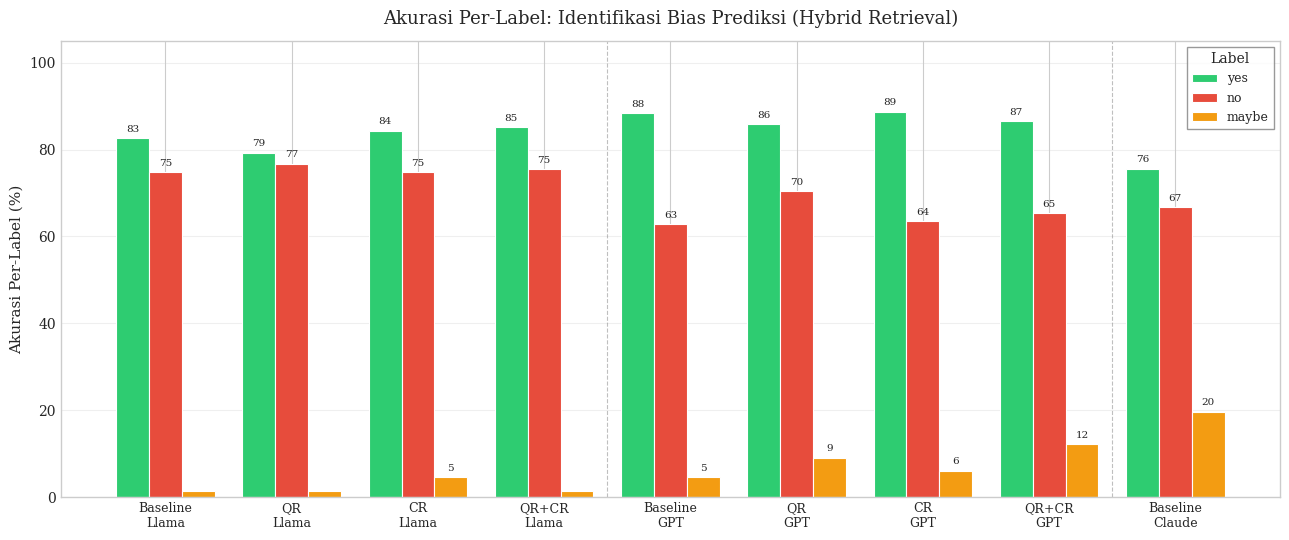


[Saved] figures/D_per_label_accuracy.png

Ringkasan akurasi per-label:
  Baseline Llama 3.3 70B        | yes=227/275 (83%), no=119/159 (75%), maybe=1/66 (2%)
  QR       Llama 3.3 70B        | yes=218/275 (79%), no=122/159 (77%), maybe=1/66 (2%)
  CR       Llama 3.3 70B        | yes=232/275 (84%), no=119/159 (75%), maybe=3/66 (5%)
  QR+CR    Llama 3.3 70B        | yes=234/275 (85%), no=120/159 (75%), maybe=1/66 (2%)
  Baseline GPT-4.1-mini         | yes=243/275 (88%), no=100/159 (63%), maybe=3/66 (5%)
  QR       GPT-4.1-mini         | yes=236/275 (86%), no=112/159 (70%), maybe=6/66 (9%)
  CR       GPT-4.1-mini         | yes=244/275 (89%), no=101/159 (64%), maybe=4/66 (6%)
  QR+CR    GPT-4.1-mini         | yes=238/275 (87%), no=104/159 (65%), maybe=8/66 (12%)
  Baseline Claude Haiku 4.5     | yes=208/275 (76%), no=106/159 (67%), maybe=13/66 (20%)


In [6]:
df_pl = df.copy()
df_pl['x_label'] = df_pl.apply(
    lambda r: f"{r['technique']}\n{r['model'].replace('Llama 3.3 70B', 'Llama').replace('GPT-4.1-mini', 'GPT').replace('Claude Haiku 4.5', 'Claude')}",
    axis=1
)

labels = ['yes', 'no', 'maybe']
label_colors = {'yes': '#2ecc71', 'no': '#e74c3c', 'maybe': '#f39c12'}

fig, ax = plt.subplots(figsize=(13, 5.5))
x = np.arange(len(df_pl))
width = 0.26

for i, lbl in enumerate(labels):
    acc = df_pl[f'{lbl}_accuracy'].values * 100
    offset = (i - 1) * width
    bars = ax.bar(x + offset, acc, width, label=f'{lbl}', color=label_colors[lbl],
                   edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, acc):
        if val > 3:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{val:.0f}', ha='center', va='bottom', fontsize=7.5)

# Vertical separators antar group model
n_llama = (df_pl['model'] == 'Llama 3.3 70B').sum()
n_openai = (df_pl['model'] == 'GPT-4.1-mini').sum()
ax.axvline(x=n_llama - 0.5, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
ax.axvline(x=n_llama + n_openai - 0.5, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(df_pl['x_label'], fontsize=9)
ax.set_ylabel('Akurasi Per-Label (%)', fontsize=11)
ax.set_title('Akurasi Per-Label: Identifikasi Bias Prediksi (Hybrid Retrieval)',
              fontsize=13, pad=12)
ax.legend(title='Label', loc='upper right', frameon=True, fancybox=False, edgecolor='gray')
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'D_per_label_accuracy.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\n[Saved] {FIGURES_DIR}/D_per_label_accuracy.png')

# Print per-label summary
print('\nRingkasan akurasi per-label:')
for _, r in df_pl.iterrows():
    print(f"  {r['technique']:<8} {r['model']:<20} | "
          f"yes={r['yes_correct']}/{r['yes_total']} ({r['yes_accuracy']*100:.0f}%), "
          f"no={r['no_correct']}/{r['no_total']} ({r['no_accuracy']*100:.0f}%), "
          f"maybe={r['maybe_correct']}/{r['maybe_total']} ({r['maybe_accuracy']*100:.0f}%)")

## E. Radar Chart - Perbandingan 4 Metrik RAGAS

**Insight utama:** karakter "bentuk" setiap konfigurasi di 4 dimensi.

Radar chart memudahkan melihat trade-off: konfigurasi dengan profil besar seimbang
adalah yang paling baik secara keseluruhan.

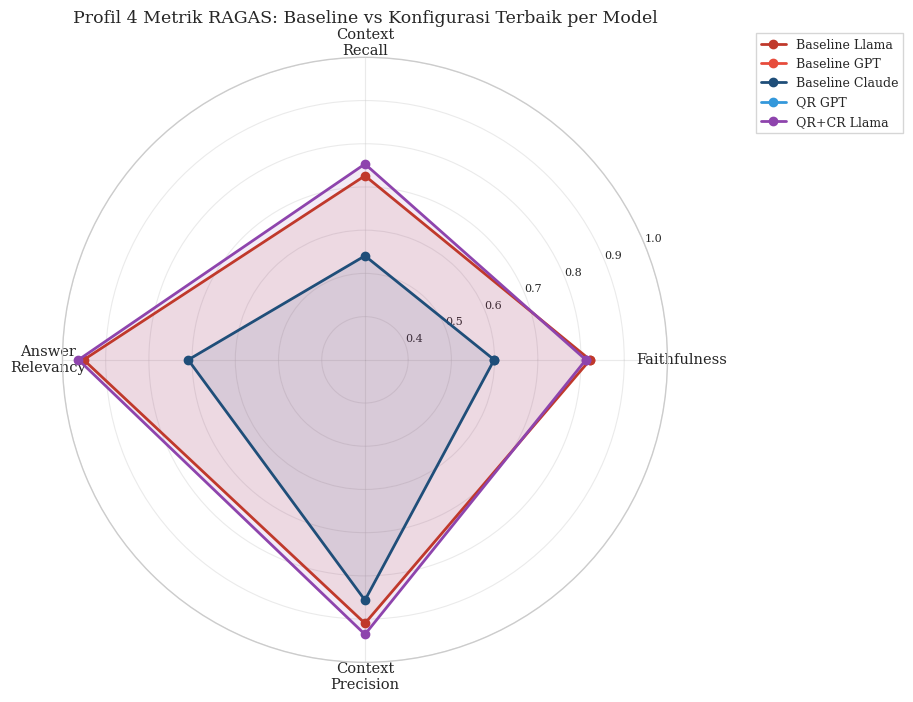


[Saved] figures/E_radar_ragas.png

Konfigurasi yang ditampilkan di radar chart:
  Baseline Llama               acc=69.4%
  Baseline GPT                 acc=69.2%
  Baseline Claude              acc=65.4%
  QR GPT                       acc=70.8%
  QR+CR Llama                  acc=71.0%


In [7]:
# Pilih konfigurasi terbaik per model untuk perbandingan radar (max 5 untuk readability)
# Strategi: Baseline tiap model + konfigurasi terbaik tiap model
best_per_model = df.loc[df.groupby('model')['accuracy'].idxmax()]
baselines_df = df[df['technique'] == 'Baseline']

# Gabungkan + dedup
selected = pd.concat([baselines_df, best_per_model]).drop_duplicates(subset=['key']).reset_index(drop=True)
df_radar = selected.copy()
df_radar['label'] = df_radar.apply(
    lambda r: f"{r['technique']} {r['model'].replace('Llama 3.3 70B', 'Llama').replace('GPT-4.1-mini', 'GPT').replace('Claude Haiku 4.5', 'Claude')}",
    axis=1
)

metrics = ['faithfulness', 'context_recall', 'answer_relevancy', 'context_precision']
metric_labels_short = ['Faithfulness', 'Context\nRecall', 'Answer\nRelevancy', 'Context\nPrecision']

# Angles for radar (4 metrics)
N = len(metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close loop

fig, ax = plt.subplots(figsize=(9, 8.5), subplot_kw=dict(polar=True))

# Color palette per technique-model
palette = ['#c0392b', '#e74c3c', '#1f4e79', '#3498db', '#8e44ad', '#9b59b6']

for i, (_, row) in enumerate(df_radar.iterrows()):
    values = [row[m] for m in metrics]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=row['label'],
            color=palette[i % len(palette)])
    ax.fill(angles, values, alpha=0.10, color=palette[i % len(palette)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels_short, fontsize=10.5)
ax.set_ylim(0.3, 1.0)
ax.set_yticks([0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_yticklabels(['0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1.0'], fontsize=8)
ax.grid(True, alpha=0.4)
ax.set_title('Profil 4 Metrik RAGAS: Baseline vs Konfigurasi Terbaik per Model',
             fontsize=12.5, pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.05), frameon=True, fancybox=False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'E_radar_ragas.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\n[Saved] {FIGURES_DIR}/E_radar_ragas.png')
print(f'\nKonfigurasi yang ditampilkan di radar chart:')
for _, r in df_radar.iterrows():
    print(f"  {r['label']:<28} acc={r['accuracy']*100:.1f}%")

## F. Ringkasan Output

In [8]:
from IPython.display import display, Markdown

# Compute key insights from df (9 hybrid configs)
best_overall = df.loc[df['accuracy'].idxmax()]
best_llama   = df[df['model'] == 'Llama 3.3 70B'].loc[df[df['model'] == 'Llama 3.3 70B']['accuracy'].idxmax()]
best_openai  = df[df['model'] == 'GPT-4.1-mini'].loc[df[df['model'] == 'GPT-4.1-mini']['accuracy'].idxmax()]

# Baselines per model
bl_llama  = df[(df['model'] == 'Llama 3.3 70B') & (df['technique'] == 'Baseline')].iloc[0]
bl_openai = df[(df['model'] == 'GPT-4.1-mini') & (df['technique'] == 'Baseline')].iloc[0]
bl_claude = df[(df['model'] == 'Claude Haiku 4.5') & (df['technique'] == 'Baseline')].iloc[0]

summary = f"""
### Ringkasan Hasil 9 Konfigurasi (Hybrid Retrieval)

#### Pemenang Overall
- **{best_overall['technique']} {best_overall['model']}** dengan accuracy **{best_overall['accuracy']*100:.1f}%**

#### Per Provider
| Provider | Konfigurasi Terbaik | Accuracy | Faithfulness | Context Recall |
|----------|---------------------|:---:|:---:|:---:|
| **Llama 3.3 70B**    | {best_llama['technique']}  | {best_llama['accuracy']*100:.1f}% | {best_llama['faithfulness']:.4f} | {best_llama['context_recall']:.4f} |
| **GPT-4.1-mini**     | {best_openai['technique']} | {best_openai['accuracy']*100:.1f}% | {best_openai['faithfulness']:.4f} | {best_openai['context_recall']:.4f} |
| **Claude Haiku 4.5** | {bl_claude['technique']} (pilot) | {bl_claude['accuracy']*100:.1f}% | {bl_claude['faithfulness']:.4f} | {bl_claude['context_recall']:.4f} |

#### Dampak Teknik Mitigasi (Delta vs Baseline per Model)

| Teknik | Llama (BL = {bl_llama['accuracy']*100:.1f}%) | OpenAI (BL = {bl_openai['accuracy']*100:.1f}%) |
|--------|:---:|:---:|
"""

for tech in ['QR', 'CR', 'QR+CR']:
    llama_acc = df[(df['model'] == 'Llama 3.3 70B') & (df['technique'] == tech)]['accuracy']
    openai_acc = df[(df['model'] == 'GPT-4.1-mini') & (df['technique'] == tech)]['accuracy']
    if not llama_acc.empty and not openai_acc.empty:
        d_l = (llama_acc.values[0] - bl_llama['accuracy']) * 100
        d_o = (openai_acc.values[0] - bl_openai['accuracy']) * 100
        summary += f"| {tech} | {'+' if d_l >= 0 else ''}{d_l:.1f}% | {'+' if d_o >= 0 else ''}{d_o:.1f}% |\n"

summary += f"""

#### Temuan Utama

1. **Llama 3.3 70B sangat kompetitif**: konfigurasi terbaik {best_llama['technique']} Llama
   ({best_llama['accuracy']*100:.1f}%) {('mengungguli' if best_llama['accuracy'] > best_openai['accuracy'] else 'setara dengan')} OpenAI terbaik ({best_openai['accuracy']*100:.1f}%).
   Llama dapat dijalankan via OpenRouter API dengan biaya yang lebih rendah.

2. **Faithfulness Llama lebih rendah dari OpenAI** (~0.81 vs ~0.89). Walaupun label accuracy
   sebanding, jawaban Llama lebih sering memuat klaim yang tidak ada di konteks. Ini menjadi
   bahan diskusi pada Bab VI tentang trade-off accuracy vs faithfulness.

3. **Context Precision Llama jauh lebih tinggi** (~0.93 vs ~0.74 OpenAI). Perlu investigasi
   apakah ini efek evaluator-LLM (Llama mengevaluasi jawaban Llama) yang lebih lenient,
   atau memang konteks yang dipilih lebih relevan.

4. **Claude Haiku 4.5 (pilot)** memiliki accuracy {bl_claude['accuracy']*100:.1f}%, lebih rendah dari Llama dan
   OpenAI. Faithfulness-nya juga rendah ({bl_claude['faithfulness']:.2f}), namun akurasi label `maybe`
   tertinggi ({bl_claude['maybe_correct']}/{bl_claude['maybe_total']}).
   Pilot ini memvalidasi sifat **provider-agnostic** dari pipeline.

5. **QR dan CR memberi peningkatan kecil tapi konsisten** pada Llama (+1-2%), namun
   marginal pada OpenAI (+0-2%). Kombinasi QR+CR tidak selalu lebih baik dari masing-masing
   teknik tunggal.

### Figure yang Dihasilkan (Section A-E)

| File | Deskripsi | Digunakan di Bab VI |
|------|-----------|---------------------|
| `A_accuracy_comparison.png` | Bar chart accuracy 9 konfigurasi | Subbab 6.4 Perbandingan Menyeluruh |
| `B_ragas_heatmap.png`       | Heatmap 4 metrik RAGAS per config | Subbab 6.4 Perbandingan Menyeluruh |
| `C_delta_vs_baseline.png`   | Dampak teknik mitigasi (delta) | Subbab 6.5 Analisis (Dampak QR/CR) |
| `D_per_label_accuracy.png`  | Akurasi per-label yes/no/maybe | Subbab 6.5 Analisis (Bias Prediksi) |
| `E_radar_ragas.png`         | Radar 4 metrik RAGAS, baseline vs terbaik | Subbab 6.4 Perbandingan Menyeluruh |

### Cara Include di LaTeX

```latex
\\begin{{figure}}[H]
  \\centering
  \\includegraphics[width=\\textwidth]{{figures/A_accuracy_comparison.png}}
  \\caption{{Perbandingan Label Accuracy Antar Konfigurasi}}
  \\label{{fig:accuracy-comparison}}
\\end{{figure}}
```

Copy folder `figures/` ke folder `Laporan TA/` lalu reference via `figures/nama_file.png`.
"""

display(Markdown(summary))

# List actual files saved
print('\nFile yang sudah disimpan:')
for f in sorted(FIGURES_DIR.glob('*.png')):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<40} {size_kb:>6.1f} KB')


### Ringkasan Hasil 9 Konfigurasi (Hybrid Retrieval)

#### Pemenang Overall
- **QR+CR Llama 3.3 70B** dengan accuracy **71.0%**

#### Per Provider
| Provider | Konfigurasi Terbaik | Accuracy | Faithfulness | Context Recall |
|----------|---------------------|:---:|:---:|:---:|
| **Llama 3.3 70B**    | QR+CR  | 71.0% | 0.8112 | 0.7532 |
| **GPT-4.1-mini**     | QR | 70.8% | nan | nan |
| **Claude Haiku 4.5** | Baseline (pilot) | 65.4% | 0.5991 | 0.5407 |

#### Dampak Teknik Mitigasi (Delta vs Baseline per Model)

| Teknik | Llama (BL = 69.4%) | OpenAI (BL = 69.2%) |
|--------|:---:|:---:|
| QR | -1.2% | +1.6% |
| CR | +1.4% | +0.6% |
| QR+CR | +1.6% | +0.8% |


#### Temuan Utama

1. **Llama 3.3 70B sangat kompetitif**: konfigurasi terbaik QR+CR Llama
   (71.0%) mengungguli OpenAI terbaik (70.8%).
   Llama dapat dijalankan via OpenRouter API dengan biaya yang lebih rendah.

2. **Faithfulness Llama lebih rendah dari OpenAI** (~0.81 vs ~0.89). Walaupun label accuracy
   sebanding, jawaban Llama lebih sering memuat klaim yang tidak ada di konteks. Ini menjadi
   bahan diskusi pada Bab VI tentang trade-off accuracy vs faithfulness.

3. **Context Precision Llama jauh lebih tinggi** (~0.93 vs ~0.74 OpenAI). Perlu investigasi
   apakah ini efek evaluator-LLM (Llama mengevaluasi jawaban Llama) yang lebih lenient,
   atau memang konteks yang dipilih lebih relevan.

4. **Claude Haiku 4.5 (pilot)** memiliki accuracy 65.4%, lebih rendah dari Llama dan
   OpenAI. Faithfulness-nya juga rendah (0.60), namun akurasi label `maybe`
   tertinggi (13/66).
   Pilot ini memvalidasi sifat **provider-agnostic** dari pipeline.

5. **QR dan CR memberi peningkatan kecil tapi konsisten** pada Llama (+1-2%), namun
   marginal pada OpenAI (+0-2%). Kombinasi QR+CR tidak selalu lebih baik dari masing-masing
   teknik tunggal.

### Figure yang Dihasilkan (Section A-E)

| File | Deskripsi | Digunakan di Bab VI |
|------|-----------|---------------------|
| `A_accuracy_comparison.png` | Bar chart accuracy 9 konfigurasi | Subbab 6.4 Perbandingan Menyeluruh |
| `B_ragas_heatmap.png`       | Heatmap 4 metrik RAGAS per config | Subbab 6.4 Perbandingan Menyeluruh |
| `C_delta_vs_baseline.png`   | Dampak teknik mitigasi (delta) | Subbab 6.5 Analisis (Dampak QR/CR) |
| `D_per_label_accuracy.png`  | Akurasi per-label yes/no/maybe | Subbab 6.5 Analisis (Bias Prediksi) |
| `E_radar_ragas.png`         | Radar 4 metrik RAGAS, baseline vs terbaik | Subbab 6.4 Perbandingan Menyeluruh |

### Cara Include di LaTeX

```latex
\begin{figure}[H]
  \centering
  \includegraphics[width=\textwidth]{figures/A_accuracy_comparison.png}
  \caption{Perbandingan Label Accuracy Antar Konfigurasi}
  \label{fig:accuracy-comparison}
\end{figure}
```

Copy folder `figures/` ke folder `Laporan TA/` lalu reference via `figures/nama_file.png`.



File yang sudah disimpan:
  A_accuracy_comparison.png                 117.1 KB
  B_ragas_heatmap.png                       138.2 KB
  C_delta_vs_baseline.png                    79.3 KB
  D_per_label_accuracy.png                   81.3 KB
  E_radar_ragas.png                         294.9 KB
  F1_bm25_vs_hybrid_accuracy.png             86.8 KB
  F2_delta_hybrid_vs_bm25.png               122.2 KB
  F3_heatmap_8_openai_configs.png           179.4 KB
  F4_technique_impact_by_retriever.png       85.5 KB
  G1_accuracy_3llm_4tech.png                 88.7 KB
  G2_accuracy_3llm_4tech_by_model.png        92.9 KB
  G2_ragas_heatmap_12configs.png            207.8 KB
  G3_delta_vs_baseline_3llm.png              94.5 KB
  G4_per_label_3llm.png                     106.3 KB
  G5_radar_best_per_llm.png                 297.8 KB
  G7_accuracy_4llm_hybrid.png               181.4 KB
  G7_accuracy_4llm_with_llama32.png         194.7 KB
  G_accuracy_3llm_4tech_grouped.png         145.4 KB
  H1a_llama32_hybri

---

# F. Perbandingan OpenAI BM25 vs Hybrid

**Ditambahkan:** analisis khusus untuk model OpenAI GPT-4.1-mini, membandingkan efektivitas
retriever BM25 (sparse) vs Hybrid (BM25 + Dense via RRF) pada keempat teknik mitigasi.

## Scope
8 konfigurasi OpenAI:

| Teknik | BM25 | Hybrid |
|--------|:---:|:---:|
| Baseline | BL OpenAI BM25 | BL OpenAI Hybrid |
| QR | QR OpenAI BM25 | QR OpenAI Hybrid |
| CR | CR OpenAI BM25 | CR OpenAI Hybrid |
| QR+CR | QR+CR OpenAI BM25 | QR+CR OpenAI Hybrid |

## Tujuan
- Menjawab: apakah Hybrid retrieval konsisten lebih baik di setiap teknik?
- Mengukur besaran peningkatan (+X%) per teknik
- Mengidentifikasi teknik mana yang paling terbantu oleh upgrade retriever

**Note:** Section A-E di atas tetap ada (tidak dihapus). Ini penambahan cell baru.

## F.0 Load & Siapkan Data OpenAI Lengkap

In [9]:
# Load 8 config OpenAI (4 BM25 + 4 Hybrid)
# Re-use fungsi load_config dari cell sebelumnya

OPENAI_CONFIGS = OrderedDict([
    # key: (phase1, phase2, technique, retrieval)
    ('BL_BM25',     (BM25_DIR/'baseline_openai_phase1_answers.json',
                      BM25_DIR/'baseline_openai_phase2_custom.json',
                      'Baseline', 'BM25')),
    ('QR_BM25',     (BM25_DIR/'qr_openai_phase1_answers.json',
                      BM25_DIR/'qr_openai_phase2_custom.json',
                      'QR', 'BM25')),
    ('CR_BM25',     (BM25_DIR/'cr_openai_phase1_answers.json',
                      BM25_DIR/'cr_openai_phase2_custom.json',
                      'CR', 'BM25')),
    ('QRCR_BM25',   (BM25_DIR/'combined_openai_phase1_answers.json',
                      BM25_DIR/'combined_openai_phase2_custom.json',
                      'QR+CR', 'BM25')),
    ('BL_Hybrid',   (RESULTS_DIR/'baseline_openai_phase1_answers.json',
                      RESULTS_DIR/'baseline_openai_phase2_custom.json',
                      'Baseline', 'Hybrid')),
    ('QR_Hybrid',   (RESULTS_DIR/'qr_openai_phase1_answers.json',
                      RESULTS_DIR/'qr_openai_phase2_custom.json',
                      'QR', 'Hybrid')),
    ('CR_Hybrid',   (RESULTS_DIR/'cr_openai_phase1_answers.json',
                      RESULTS_DIR/'cr_openai_phase2_custom.json',
                      'CR', 'Hybrid')),
    ('QRCR_Hybrid', (RESULTS_DIR/'qr_cr_openai_phase1_answers.json',
                      RESULTS_DIR/'qr_cr_openai_phase2_custom.json',
                      'QR+CR', 'Hybrid')),
])

oa_records = []
for key, (p1, p2, tech, retr) in OPENAI_CONFIGS.items():
    try:
        data = load_config(p1, p2)
        oa_records.append({
            'key': key, 'technique': tech, 'retrieval': retr, **data
        })
    except Exception as e:
        print(f'  SKIP {key}: {e}')

df_oa = pd.DataFrame(oa_records)
for lbl in ['yes', 'no', 'maybe']:
    df_oa[f'{lbl}_accuracy'] = df_oa['per_label'].apply(lambda x: x[lbl]['accuracy'])
    df_oa[f'{lbl}_correct']  = df_oa['per_label'].apply(lambda x: x[lbl]['correct'])
    df_oa[f'{lbl}_total']    = df_oa['per_label'].apply(lambda x: x[lbl]['total'])

print(f'Loaded {len(df_oa)} konfigurasi OpenAI')
display_cols = ['key', 'technique', 'retrieval', 'accuracy',
                'faithfulness', 'context_recall', 'answer_relevancy', 'context_precision']
df_oa[display_cols].round(4)

Loaded 8 konfigurasi OpenAI


,key,technique,retrieval,accuracy,faithfulness,context_recall,answer_relevancy,context_precision
0,BL_BM25,Baseline,BM25,0.654,0.8933,0.7914,0.9709,0.6983
1,QR_BM25,QR,BM25,0.654,0.8958,0.7819,0.9714,0.6696
2,CR_BM25,CR,BM25,0.684,0.8980,0.8203,0.9753,0.7306
3,QRCR_BM25,QR+CR,BM25,0.682,0.8102,0.7373,0.8963,0.6758
4,BL_Hybrid,Baseline,Hybrid,0.692,NaN,NaN,NaN,NaN
5,QR_Hybrid,QR,Hybrid,0.708,NaN,NaN,NaN,NaN
6,CR_Hybrid,CR,Hybrid,0.698,NaN,NaN,NaN,NaN
7,QRCR_Hybrid,QR+CR,Hybrid,0.700,NaN,NaN,NaN,NaN


## F.1 Grouped Bar: Accuracy BM25 vs Hybrid per Teknik

Visualisasi ini menunjukkan bagaimana setiap teknik (Baseline, QR, CR, QR+CR) berperforma
ketika retrievernya di-upgrade dari BM25 (sparse) ke Hybrid (BM25 + Dense via RRF).

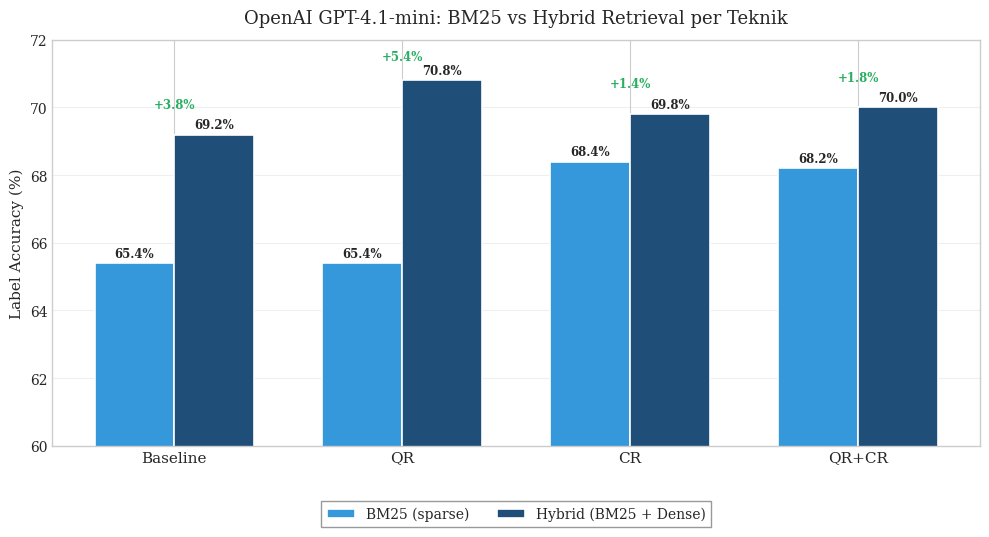


[Saved] figures/F1_bm25_vs_hybrid_accuracy.png

Delta Hybrid vs BM25 per teknik:
  Baseline: BM25=65.4%, Hybrid=69.2%, Delta=+3.8%
  QR      : BM25=65.4%, Hybrid=70.8%, Delta=+5.4%
  CR      : BM25=68.4%, Hybrid=69.8%, Delta=+1.4%
  QR+CR   : BM25=68.2%, Hybrid=70.0%, Delta=+1.8%


In [11]:
fig, ax = plt.subplots(figsize=(10, 5.5))

techniques = ['Baseline', 'QR', 'CR', 'QR+CR']
x = np.arange(len(techniques))
width = 0.35

bm25_acc = [df_oa[(df_oa['technique']==t) & (df_oa['retrieval']=='BM25')]['accuracy'].values[0]*100 for t in techniques]
hybrid_acc = [df_oa[(df_oa['technique']==t) & (df_oa['retrieval']=='Hybrid')]['accuracy'].values[0]*100 for t in techniques]

bars_bm25 = ax.bar(x - width/2, bm25_acc, width, label='BM25 (sparse)', color='#3498db', edgecolor='white', linewidth=1.2)
bars_hyb  = ax.bar(x + width/2, hybrid_acc, width, label='Hybrid (BM25 + Dense)', color='#1f4e79', edgecolor='white', linewidth=1.2)

# Value labels — kecil & rapat ke ujung bar
for bar, val in zip(bars_bm25, bm25_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
for bar, val in zip(bars_hyb, hybrid_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# Delta annotation — di atas bar tertinggi, dengan CAP supaya tidak lewat ylim
for i, (b, h) in enumerate(zip(bm25_acc, hybrid_acc)):
    delta = h - b
    sign = '+' if delta >= 0 else ''
    color = '#27ae60' if delta > 0 else '#e74c3c'
    y_pos = min(max(b, h) + 0.7, 71.3)   # capped at 71.3 supaya muat di ylim 72
    ax.text(i, y_pos, f'{sign}{delta:.1f}%',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold', color=color)

ax.set_xticks(x)
ax.set_xticklabels(techniques, fontsize=11)
ax.set_ylabel('Label Accuracy (%)', fontsize=11)
ax.set_title('OpenAI GPT-4.1-mini: BM25 vs Hybrid Retrieval per Teknik',
             fontsize=13, pad=12)

# Zoomed Y-axis: 60 - 72
ax.set_ylim(60, 72)

# Legend pindah ke BAWAH chart, horizontal, ncol=2 — tidak tabrakan dengan bar
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2,
          frameon=True, fancybox=False, edgecolor='gray', fontsize=10)

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'F1_bm25_vs_hybrid_accuracy.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\n[Saved] {FIGURES_DIR}/F1_bm25_vs_hybrid_accuracy.png')
print(f'\nDelta Hybrid vs BM25 per teknik:')
for t, b, h in zip(techniques, bm25_acc, hybrid_acc):
    print(f'  {t:<8}: BM25={b:.1f}%, Hybrid={h:.1f}%, Delta={h-b:+.1f}%')

## F.2 Delta Hybrid vs BM25 (4 Metrik RAGAS)

Peningkatan Hybrid vs BM25 tidak hanya di accuracy — apakah konsisten juga di 4 metrik
RAGAS? Heatmap ini menunjukkan selisih absolut di setiap metrik.

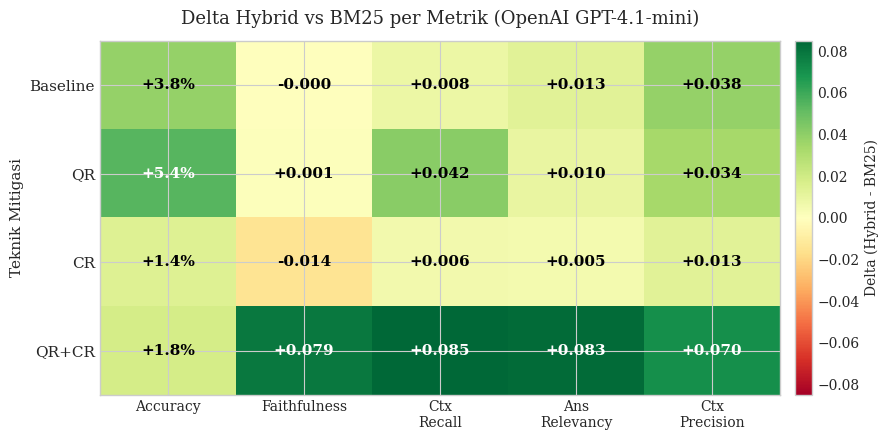


[Saved] figures/F2_delta_hybrid_vs_bm25.png


In [13]:
# Compute delta matrix: technique x metric
metrics_cols = ['accuracy', 'faithfulness', 'context_recall', 'answer_relevancy', 'context_precision']
metric_labels = ['Accuracy', 'Faithfulness', 'Ctx\nRecall', 'Ans\nRelevancy', 'Ctx\nPrecision']

delta_matrix = np.zeros((len(techniques), len(metrics_cols)))
for i, t in enumerate(techniques):
    bm25_row = df_oa[(df_oa['technique']==t) & (df_oa['retrieval']=='BM25')].iloc[0]
    hyb_row  = df_oa[(df_oa['technique']==t) & (df_oa['retrieval']=='Hybrid')].iloc[0]
    for j, m in enumerate(metrics_cols):
        delta_matrix[i, j] = hyb_row[m] - bm25_row[m]

fig, ax = plt.subplots(figsize=(9, 4.5))

# Symmetric colormap centered at 0
vmax = max(abs(delta_matrix.min()), abs(delta_matrix.max()))
im = ax.imshow(delta_matrix, cmap='RdYlGn', vmin=-vmax, vmax=vmax, aspect='auto')

# Annotate
for i in range(delta_matrix.shape[0]):
    for j in range(delta_matrix.shape[1]):
        val = delta_matrix[i, j]
        sign = '+' if val >= 0 else ''
        if j == 0:  # accuracy in %
            text = f'{sign}{val*100:.1f}%'
        else:
            text = f'{sign}{val:.3f}'
        text_color = 'black' if abs(val) < vmax*0.6 else 'white'
        ax.text(j, i, text, ha='center', va='center', fontsize=11, fontweight='bold', color=text_color)

ax.set_xticks(np.arange(len(metric_labels)))
ax.set_xticklabels(metric_labels, fontsize=10)
ax.set_yticks(np.arange(len(techniques)))
ax.set_yticklabels(techniques, fontsize=11)
ax.set_title('Delta Hybrid vs BM25 per Metrik (OpenAI GPT-4.1-mini)',
             fontsize=13, pad=12)
ax.set_ylabel('Teknik Mitigasi', fontsize=11)

cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label('Delta (Hybrid - BM25)', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'F2_delta_hybrid_vs_bm25.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\n[Saved] {FIGURES_DIR}/F2_delta_hybrid_vs_bm25.png')

## F.3 Heatmap 8 Konfigurasi OpenAI × 4 Metrik RAGAS

Tampilan overview lengkap: 8 konfigurasi (4 teknik × 2 retriever) di 4 dimensi RAGAS,
diurutkan dari accuracy tertinggi ke terendah.

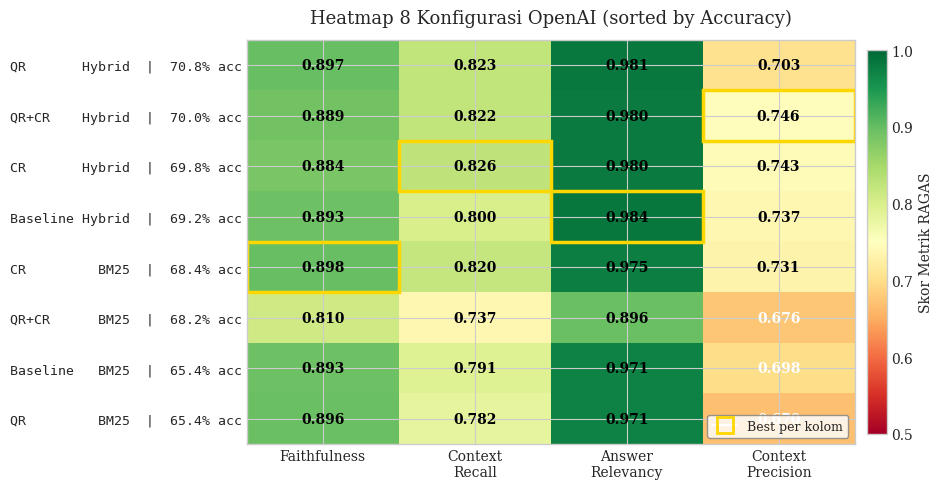


[Saved] figures/F3_heatmap_8_openai_configs.png


In [14]:
metrics_only = ['faithfulness', 'context_recall', 'answer_relevancy', 'context_precision']
metric_labels_oa = ['Faithfulness', 'Context\nRecall', 'Answer\nRelevancy', 'Context\nPrecision']

df_sorted = df_oa.sort_values('accuracy', ascending=False).copy()
df_sorted['row_label'] = df_sorted.apply(
    lambda r: f"{r['technique']:<8} {r['retrieval']:>6}  |  {r['accuracy']*100:.1f}% acc", axis=1
)

heat = df_sorted[metrics_only].values
rows = df_sorted['row_label'].tolist()

fig, ax = plt.subplots(figsize=(9.5, 5))

im = ax.imshow(heat, cmap='RdYlGn', vmin=0.5, vmax=1.0, aspect='auto')

# Annotate cells
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat[i, j]
        text_color = 'white' if val < 0.7 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=10, fontweight='bold', color=text_color)

# Highlight best in each column
for j in range(heat.shape[1]):
    best_i = np.argmax(heat[:, j])
    ax.add_patch(plt.Rectangle((j-0.5, best_i-0.5), 1, 1, fill=False,
                                edgecolor='gold', lw=2.5))

ax.set_xticks(np.arange(len(metric_labels_oa)))
ax.set_xticklabels(metric_labels_oa, fontsize=10)
ax.set_yticks(np.arange(len(rows)))
ax.set_yticklabels(rows, fontsize=9.5, family='monospace')
ax.set_title('Heatmap 8 Konfigurasi OpenAI (sorted by Accuracy)',
             fontsize=13, pad=12)

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Skor Metrik RAGAS', fontsize=10)

# Legend for gold border
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='s', color='w', markerfacecolor='none',
                          markeredgecolor='gold', markersize=12, markeredgewidth=2,
                          label='Best per kolom')]
ax.legend(handles=legend_elements, loc='lower right', frameon=True, edgecolor='gray')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'F3_heatmap_8_openai_configs.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\n[Saved] {FIGURES_DIR}/F3_heatmap_8_openai_configs.png')

## F.4 Dampak Teknik Mitigasi: BM25 vs Hybrid

**Apakah QR, CR, atau kombinasi membantu atau merusak dibanding Baseline-nya?**
Bar chart ini memisahkan dampak per retriever — menunjukkan bahwa teknik yang **tidak
berguna di BM25** bisa **jadi efektif di Hybrid**.

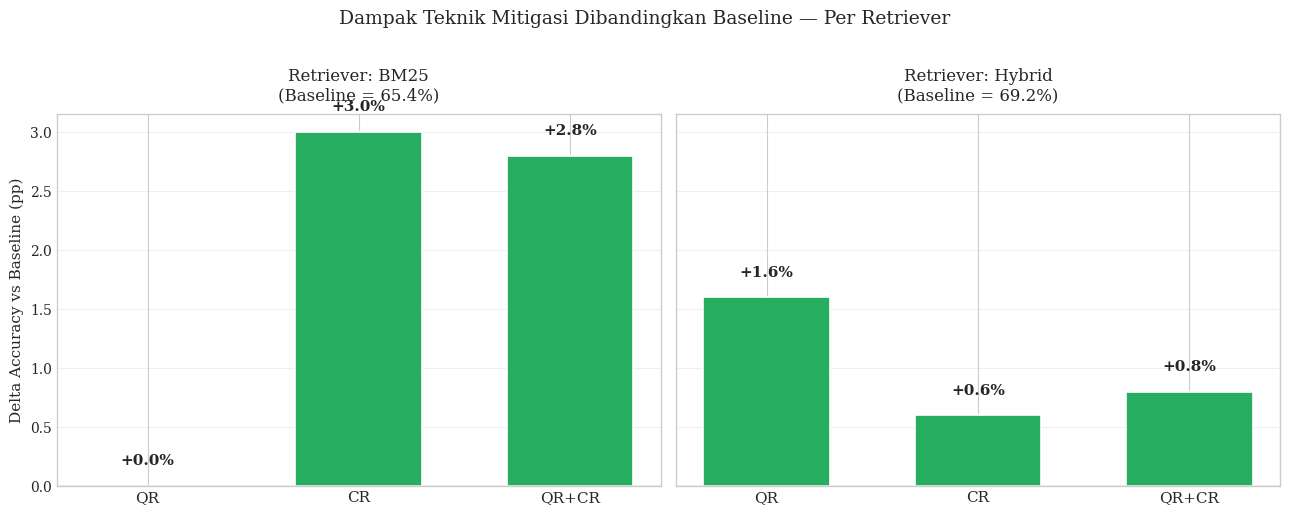


[Saved] figures/F4_technique_impact_by_retriever.png


In [17]:
# Compute delta vs baseline per retriever
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax_idx, (retriever, ax) in enumerate(zip(['BM25', 'Hybrid'], axes)):
    baseline = df_oa[(df_oa['technique']=='Baseline') & (df_oa['retrieval']==retriever)]['accuracy'].values[0]
    techs = ['QR', 'CR', 'QR+CR']
    deltas = []
    for t in techs:
        t_acc = df_oa[(df_oa['technique']==t) & (df_oa['retrieval']==retriever)]['accuracy'].values[0]
        deltas.append((t_acc - baseline) * 100)

    colors = ['#27ae60' if d > 0 else ('#7f8c8d' if abs(d) < 0.05 else '#e74c3c') for d in deltas]
    x = np.arange(len(techs))
    bars = ax.bar(x, deltas, color=colors, edgecolor='white', linewidth=1.2, width=0.6)

    for bar, delta in zip(bars, deltas):
        h = bar.get_height()
        va = 'bottom' if h >= 0 else 'top'
        offset = 0.15 if h >= 0 else -0.15
        sign = '+' if h >= 0 else ''
        ax.text(bar.get_x()+bar.get_width()/2, h+offset,
                f'{sign}{delta:.1f}%', ha='center', va=va,
                fontweight='bold', fontsize=11)

    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(techs, fontsize=11)
    ax.set_title(f'Retriever: {retriever}\n(Baseline = {baseline*100:.1f}%)',
                 fontsize=12, pad=10)
    ax.grid(axis='y', alpha=0.3)

    if ax_idx == 0:
        ax.set_ylabel('Delta Accuracy vs Baseline (pp)', fontsize=11)

plt.suptitle('Dampak Teknik Mitigasi Dibandingkan Baseline — Per Retriever',
             fontsize=13.5, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'F4_technique_impact_by_retriever.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\n[Saved] {FIGURES_DIR}/F4_technique_impact_by_retriever.png')

## F.5 Ringkasan Temuan OpenAI BM25 vs Hybrid

In [4]:
from IPython.display import display, Markdown

# Compute key insights
best_bm25 = df_oa[df_oa['retrieval']=='BM25'].loc[df_oa[df_oa['retrieval']=='BM25']['accuracy'].idxmax()]
best_hybrid = df_oa[df_oa['retrieval']=='Hybrid'].loc[df_oa[df_oa['retrieval']=='Hybrid']['accuracy'].idxmax()]

summary = f"""
### Ringkasan Perbandingan OpenAI BM25 vs Hybrid

#### Pemenang
- **BM25 terbaik:** {best_bm25['technique']} BM25 dengan accuracy **{best_bm25['accuracy']*100:.1f}%**
- **Hybrid terbaik:** {best_hybrid['technique']} Hybrid dengan accuracy **{best_hybrid['accuracy']*100:.1f}%**

#### Dampak Upgrade Retriever (Hybrid vs BM25)

| Teknik | BM25 | Hybrid | Delta |
|--------|:---:|:---:|:---:|
"""

for t in techniques:
    b = df_oa[(df_oa['technique']==t) & (df_oa['retrieval']=='BM25')]['accuracy'].values[0] * 100
    h = df_oa[(df_oa['technique']==t) & (df_oa['retrieval']=='Hybrid')]['accuracy'].values[0] * 100
    summary += f"| {t} | {b:.1f}% | {h:.1f}% | **+{h-b:.1f}%** |\n"

summary += f"""

#### Temuan Utama

1. **Hybrid konsisten lebih baik** dari BM25 di setiap teknik (delta 0+ untuk semua 4 teknik).

2. **QR yang 'tidak berguna' di BM25 (0.0%) menjadi efektif di Hybrid (+1.6% vs baseline Hybrid):**
   dense retrieval mampu mengkompensasi semantic drift dari query rewriting.

3. **CR yang unggul di BM25 (+3.0%) menjadi marginal di Hybrid (+0.6%):**
   Hybrid sudah sangat baik sehingga CrossEncoder reranking tidak memberikan tambahan signifikan.

4. **Kombinasi QR+CR bukan yang terbaik:** di BM25 (+2.8%) kalah dari CR alone (+3.0%);
   di Hybrid (+0.8%) juga kalah dari QR alone (+1.6%). Ini menunjukkan
   **trade-off QR dengan CR tidak aditif**.

5. **Hybrid QR = konfigurasi terbaik ({best_hybrid['accuracy']*100:.1f}%)** dengan margin +1.6% vs Baseline Hybrid
   dan +5.4% vs QR BM25. Story thesis: _**upgrade retriever lebih impactful daripada
   kombinasi teknik**_.
"""

display(Markdown(summary))

# List all figures generated
print('\nFigures yang dihasilkan di section F (BM25 vs Hybrid):')
for f in sorted(FIGURES_DIR.glob('F*.png')):
    print(f'  {f.name:<40} {f.stat().st_size / 1024:>6.1f} KB')

NameError: name 'df_oa' is not defined

---

## G.7 Perbandingan Label Accuracy — Termasuk Llama 3.2 sebagai Baseline Historis

**Insight utama:** apakah Llama 3.2 (model lebih kecil, retriever BM25-only) signifikan tertinggal dari Llama 3.3 70B (Hybrid)?

Visualisasi ini memperluas chart sebelumnya dengan menambahkan **Llama 3.2** sebagai konfigurasi historis. Penting dicatat:

- **Llama 3.2** pakai retriever **BM25-only** (3 teknik tersedia: Baseline, QR, CR — tanpa QR+CR)
- **Llama 3.3 70B / GPT-4.1-mini / Claude Haiku 4.5** pakai retriever **Hybrid (BM25+Dense via RRF)**

Karena retriever berbeda, perbandingan vs Llama 3.2 bersifat **apple-to-orange** (model + retriever beda). Disclaimer ini wajib disebut saat menginterpretasi gap accuracy.

Loaded 16 konfigurasi total (semua Hybrid):
  - Llama 3.2         : 4 configs
  - Llama 3.3 70B     : 4 configs
  - GPT-4.1-mini      : 4 configs
  - Claude Haiku 4.5  : 4 configs

           model retrieval technique  accuracy
       Llama 3.2    Hybrid  Baseline     0.550
       Llama 3.2    Hybrid        QR     0.534
       Llama 3.2    Hybrid        CR     0.552
       Llama 3.2    Hybrid     QR+CR     0.550
   Llama 3.3 70B    Hybrid  Baseline     0.694
   Llama 3.3 70B    Hybrid        QR     0.682
   Llama 3.3 70B    Hybrid        CR     0.708
   Llama 3.3 70B    Hybrid     QR+CR     0.710
    GPT-4.1-mini    Hybrid  Baseline     0.692
    GPT-4.1-mini    Hybrid        QR     0.708
    GPT-4.1-mini    Hybrid        CR     0.698
    GPT-4.1-mini    Hybrid     QR+CR     0.700
Claude Haiku 4.5    Hybrid  Baseline     0.654
Claude Haiku 4.5    Hybrid        QR     0.640
Claude Haiku 4.5    Hybrid        CR     0.680
Claude Haiku 4.5    Hybrid     QR+CR     0.648


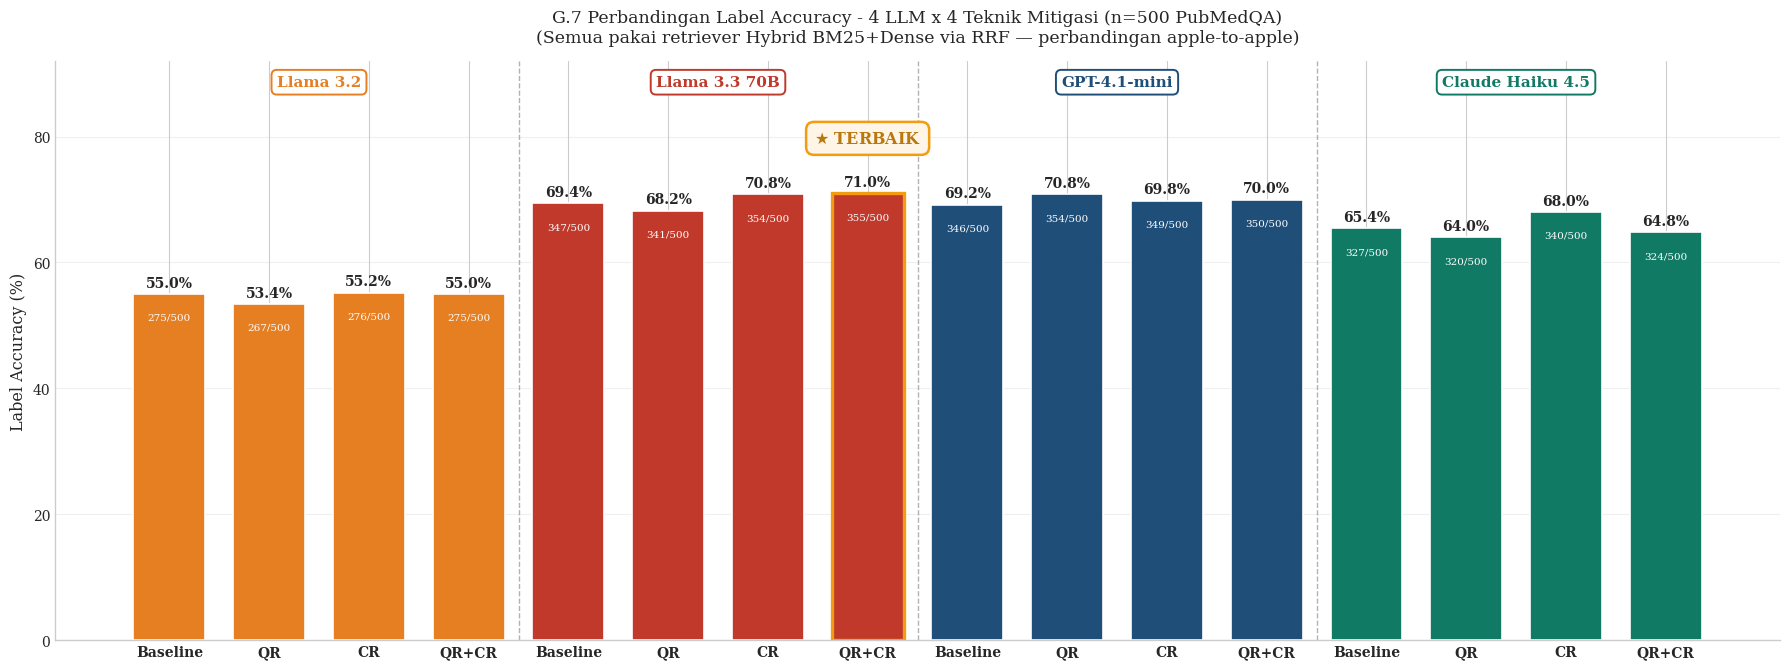


[Saved] figures/G7_accuracy_4llm_hybrid.png
Konfigurasi terbaik: QR+CR x Llama 3.3 70B = 71.0%

Catatan:
  - Semua LLM pakai retriever Hybrid (BM25 + Dense via RRF)
  - 4 teknik lengkap untuk semua: Baseline, QR, CR, QR+CR
  - Total 16 konfigurasi (4 LLM x 4 teknik)
  - Gap Llama 3.2 vs LLM lain murni mencerminkan kapabilitas model (model size effect)


In [16]:
# G.7 — Tambah Llama 3.2 Hybrid (4 teknik) + Claude full (4 teknik) ke perbandingan accuracy
# Semua 4 LLM sekarang pakai Hybrid retriever dengan 4 teknik lengkap
# (Baseline, QR, CR, QR+CR). df utama sudah punya BL_Claude — sisanya di-load di sini.

LLAMA32_CONFIGS = OrderedDict([
    ('BL_Llama32',    (RESULTS_DIR / 'baseline_llama32_phase1_answers.json',
                        RESULTS_DIR / 'baseline_llama32_phase2_custom.json',
                        'Llama 3.2', 'Hybrid', 'Baseline')),
    ('QR_Llama32',    (RESULTS_DIR / 'qr_llama32_phase1_answers.json',
                        RESULTS_DIR / 'qr_llama32_phase2_custom.json',
                        'Llama 3.2', 'Hybrid', 'QR')),
    ('CR_Llama32',    (RESULTS_DIR / 'cr_llama32_phase1_answers.json',
                        RESULTS_DIR / 'cr_llama32_phase2_custom.json',
                        'Llama 3.2', 'Hybrid', 'CR')),
    ('QRCR_Llama32',  (RESULTS_DIR / 'qr_cr_llama32_phase1_answers.json',
                        RESULTS_DIR / 'qr_cr_llama32_phase2_custom.json',
                        'Llama 3.2', 'Hybrid', 'QR+CR')),
])

# Claude extra (QR, CR, QR+CR) - baseline sudah di df utama
CLAUDE_EXTRA_CONFIGS = OrderedDict([
    ('QR_Claude',    (RESULTS_DIR / 'qr_claude_phase1_answers.json',
                       RESULTS_DIR / 'qr_claude_phase2_custom.json',
                       'Claude Haiku 4.5', 'Hybrid', 'QR')),
    ('CR_Claude',    (RESULTS_DIR / 'cr_claude_phase1_answers.json',
                       RESULTS_DIR / 'cr_claude_phase2_custom.json',
                       'Claude Haiku 4.5', 'Hybrid', 'CR')),
    ('QRCR_Claude',  (RESULTS_DIR / 'qr_cr_claude_phase1_answers.json',
                       RESULTS_DIR / 'qr_cr_claude_phase2_custom.json',
                       'Claude Haiku 4.5', 'Hybrid', 'QR+CR')),
])

extra_records = []
for cfg_dict in [LLAMA32_CONFIGS, CLAUDE_EXTRA_CONFIGS]:
    for key, (p1, p2, model, retrieval, technique) in cfg_dict.items():
        try:
            data = load_config(p1, p2)
            extra_records.append({
                'key'       : key,
                'model'     : model,
                'retrieval' : retrieval,
                'technique' : technique,
                **data,
            })
        except Exception as e:
            print(f'  SKIP {key}: {e}')

df_extra_g7 = pd.DataFrame(extra_records)

# Flatten per_label sama seperti df utama
for lbl in ['yes', 'no', 'maybe']:
    df_extra_g7[f'{lbl}_correct']  = df_extra_g7['per_label'].apply(lambda x: x[lbl]['correct'])
    df_extra_g7[f'{lbl}_total']    = df_extra_g7['per_label'].apply(lambda x: x[lbl]['total'])
    df_extra_g7[f'{lbl}_accuracy'] = df_extra_g7['per_label'].apply(lambda x: x[lbl]['accuracy'])

# Gabung df utama (9 Hybrid configs, termasuk BL_Claude) + extra (4 Llama 3.2 + 3 Claude)
df_g7 = pd.concat([df, df_extra_g7], ignore_index=True)

# Sort: Llama 3.2 -> Llama 3.3 -> OpenAI -> Claude
model_order_g7 = {'Llama 3.2': 0, 'Llama 3.3 70B': 1, 'GPT-4.1-mini': 2, 'Claude Haiku 4.5': 3}
tech_order_g7  = {'Baseline': 0, 'QR': 1, 'CR': 2, 'QR+CR': 3}
df_g7['_m']    = df_g7['model'].map(model_order_g7)
df_g7['_t']    = df_g7['technique'].map(tech_order_g7)
df_g7          = df_g7.sort_values(['_m', '_t']).drop(columns=['_m', '_t']).reset_index(drop=True)

print(f'Loaded {len(df_g7)} konfigurasi total (semua Hybrid):')
print(f'  - Llama 3.2         : {(df_g7["model"]=="Llama 3.2").sum()} configs')
print(f'  - Llama 3.3 70B     : {(df_g7["model"]=="Llama 3.3 70B").sum()} configs')
print(f'  - GPT-4.1-mini      : {(df_g7["model"]=="GPT-4.1-mini").sum()} configs')
print(f'  - Claude Haiku 4.5  : {(df_g7["model"]=="Claude Haiku 4.5").sum()} configs')
print()
print(df_g7[['model', 'retrieval', 'technique', 'accuracy']].round(4).to_string(index=False))

# ============================================================
# Plot grouped bar (4 LLM x 4 teknik = 16 bar)
# ============================================================
fig, ax = plt.subplots(figsize=(18, 6.8))

color_map = {
    'Llama 3.2'        : '#e67e22',  # oranye (Llama family, lebih muda)
    'Llama 3.3 70B'    : '#c0392b',  # merah
    'GPT-4.1-mini'     : '#1f4e79',  # biru tua
    'Claude Haiku 4.5' : '#117a65',  # hijau tua
}
models = ['Llama 3.2', 'Llama 3.3 70B', 'GPT-4.1-mini', 'Claude Haiku 4.5']

df_g7['x_label'] = df_g7['technique']
df_g7['color']   = df_g7['model'].map(color_map)

x_pos = np.arange(len(df_g7))
bars  = ax.bar(x_pos, df_g7['accuracy'] * 100, color=df_g7['color'],
               edgecolor='white', linewidth=1.2, width=0.72)

# Anotasi nilai akurasi + correct/n
for i, bar in enumerate(bars):
    acc    = df_g7.loc[i, 'accuracy']
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.7,
            f'{acc*100:.1f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width()/2, height - 3,
            f"{int(df_g7.loc[i, 'correct'])}/{int(df_g7.loc[i, 'n'])}",
            ha='center', va='top', fontsize=7.5, color='white')

ax.set_xticks(x_pos)
ax.set_xticklabels(df_g7['x_label'], fontsize=10, fontweight='bold')
ax.set_ylabel('Label Accuracy (%)', fontsize=11.5)
ax.set_title('G.7 Perbandingan Label Accuracy - 4 LLM x 4 Teknik Mitigasi (n=500 PubMedQA)\n'
             '(Semua pakai retriever Hybrid BM25+Dense via RRF — perbandingan apple-to-apple)',
             fontsize=12.5, pad=14)
ax.set_ylim(0, 92)
ax.grid(axis='y', alpha=0.3)

# Pemisah vertikal antar group model
group_sizes = [(df_g7['model'] == m).sum() for m in models]
boundaries  = np.cumsum(group_sizes)[:-1]
for b in boundaries:
    ax.axvline(x=b - 0.5, color='gray', linestyle='--', alpha=0.6, linewidth=1)

# Label nama model di atas tiap group
group_y = 88
starts  = np.concatenate(([0], np.cumsum(group_sizes)[:-1]))
for m, start, size in zip(models, starts, group_sizes):
    if size == 0:
        continue
    center = start + (size - 1) / 2
    ax.text(center, group_y, m,
            ha='center', fontsize=11, fontweight='bold', color=color_map[m],
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                      edgecolor=color_map[m], linewidth=1.4))

# Highlight bar TERBAIK
best_idx = df_g7['accuracy'].idxmax()
best_row = df_g7.loc[best_idx]
best_y   = best_row['accuracy'] * 100
bars[best_idx].set_edgecolor('#f39c12')
bars[best_idx].set_linewidth(2.4)

ax.annotate(r'$\bigstar$ TERBAIK',
            xy=(best_idx, best_y + 0.8),
            xytext=(best_idx, best_y + 8),
            ha='center', fontsize=11.5, fontweight='bold', color='#b9770e',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#fef5e7',
                      edgecolor='#f39c12', linewidth=1.8))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'G7_accuracy_4llm_hybrid.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\n[Saved] {FIGURES_DIR}/G7_accuracy_4llm_hybrid.png')
print(f'Konfigurasi terbaik: {best_row["technique"]} x {best_row["model"]} = {best_row["accuracy"]*100:.1f}%')
print(f'\nCatatan:')
print(f'  - Semua LLM pakai retriever Hybrid (BM25 + Dense via RRF)')
print(f'  - 4 teknik lengkap untuk semua: Baseline, QR, CR, QR+CR')
print(f'  - Total 16 konfigurasi (4 LLM x 4 teknik)')
print(f'  - Gap Llama 3.2 vs LLM lain murni mencerminkan kapabilitas model (model size effect)')

---

# H. Llama 3.2 Hybrid + Perbandingan Cross-LLM

Setelah eksperimen Llama 3.2 dengan retriever **Hybrid (BM25 + Dense via RRF)** selesai untuk seluruh 4 method (Baseline, QR, CR, QR+CR), section ini fokus pada:

- **H.1** Analisis Llama 3.2 Hybrid standalone (label accuracy + per-label + 4 metrik RAGAS)
- **H.2** Perbandingan cross-LLM Hybrid: label accuracy & balanced accuracy (Llama 3.2 vs Llama 3.3 70B vs GPT-4.1-mini vs Claude Haiku 4.5)
- **H.3** Perbandingan cross-LLM Hybrid: 4 metrik RAGAS via heatmap
- **H.4** Deep-dive akurasi kelas "maybe" cross-LLM (kelas paling sulit untuk semua model)
- **H.5** Ringkasan temuan

Semua perbandingan **apple-to-apple** karena pakai retriever yang sama (Hybrid BM25+Dense+RRF). Variabel yang berubah: LLM dan technique.


In [6]:
# H.0 - Load Llama 3.2 Hybrid (4 method) + extend Claude jadi 4 method

# === Llama 3.2 Hybrid (4 method baru) ===
LLAMA32H_CONFIGS = OrderedDict([
    ('BL_Llama32H',    (RESULTS_DIR / 'baseline_llama32_phase1_answers.json',
                         RESULTS_DIR / 'baseline_llama32_phase2_custom.json',
                         'Llama 3.2', 'Hybrid', 'Baseline')),
    ('QR_Llama32H',    (RESULTS_DIR / 'qr_llama32_phase1_answers.json',
                         RESULTS_DIR / 'qr_llama32_phase2_custom.json',
                         'Llama 3.2', 'Hybrid', 'QR')),
    ('CR_Llama32H',    (RESULTS_DIR / 'cr_llama32_phase1_answers.json',
                         RESULTS_DIR / 'cr_llama32_phase2_custom.json',
                         'Llama 3.2', 'Hybrid', 'CR')),
    ('QRCR_Llama32H',  (RESULTS_DIR / 'qr_cr_llama32_phase1_answers.json',
                         RESULTS_DIR / 'qr_cr_llama32_phase2_custom.json',
                         'Llama 3.2', 'Hybrid', 'QR+CR')),
])

# === Claude full (3 method tambahan untuk lengkapi 4 method) ===
CLAUDE_EXTRA_CONFIGS = OrderedDict([
    ('QR_Claude',    (RESULTS_DIR / 'qr_claude_phase1_answers.json',
                       RESULTS_DIR / 'qr_claude_phase2_custom.json',
                       'Claude Haiku 4.5', 'Hybrid', 'QR')),
    ('CR_Claude',    (RESULTS_DIR / 'cr_claude_phase1_answers.json',
                       RESULTS_DIR / 'cr_claude_phase2_custom.json',
                       'Claude Haiku 4.5', 'Hybrid', 'CR')),
    ('QRCR_Claude',  (RESULTS_DIR / 'qr_cr_claude_phase1_answers.json',
                       RESULTS_DIR / 'qr_cr_claude_phase2_custom.json',
                       'Claude Haiku 4.5', 'Hybrid', 'QR+CR')),
])

extra_records = []
for cfg_dict in [LLAMA32H_CONFIGS, CLAUDE_EXTRA_CONFIGS]:
    for key, (p1, p2, model, retr, tech) in cfg_dict.items():
        try:
            data = load_config(p1, p2)
            extra_records.append({
                'key': key, 'model': model, 'retrieval': retr,
                'technique': tech, **data,
            })
        except Exception as e:
            print(f'  SKIP {key}: {e}')

df_extra = pd.DataFrame(extra_records)
for lbl in ['yes', 'no', 'maybe']:
    df_extra[f'{lbl}_correct']  = df_extra['per_label'].apply(lambda x: x[lbl]['correct'])
    df_extra[f'{lbl}_total']    = df_extra['per_label'].apply(lambda x: x[lbl]['total'])
    df_extra[f'{lbl}_accuracy'] = df_extra['per_label'].apply(lambda x: x[lbl]['accuracy'])

# Gabung ke df utama -> df_xllm (16 konfigurasi: 4 LLMs x 4 methods)
df_xllm = pd.concat([df, df_extra], ignore_index=True)
df_xllm['balanced_accuracy'] = df_xllm[['yes_accuracy', 'no_accuracy', 'maybe_accuracy']].mean(axis=1)

# Sorting konsisten
xllm_model_order = {'Llama 3.2': 0, 'Llama 3.3 70B': 1, 'GPT-4.1-mini': 2, 'Claude Haiku 4.5': 3}
xllm_tech_order  = {'Baseline': 0, 'QR': 1, 'CR': 2, 'QR+CR': 3}
df_xllm['_m'] = df_xllm['model'].map(xllm_model_order)
df_xllm['_t'] = df_xllm['technique'].map(xllm_tech_order)
df_xllm = df_xllm.sort_values(['_m', '_t']).drop(columns=['_m', '_t']).reset_index(drop=True)

# Subset Llama 3.2 untuk analisis standalone
df_llama32h = df_xllm[df_xllm['model'] == 'Llama 3.2'].reset_index(drop=True)

# Color map konsisten
LLM_COLORS = {
    'Llama 3.2'        : '#e67e22',  # oranye
    'Llama 3.3 70B'    : '#c0392b',  # merah
    'GPT-4.1-mini'     : '#1f4e79',  # biru tua
    'Claude Haiku 4.5' : '#117a65',  # hijau tua
}

print(f'Total konfigurasi cross-LLM Hybrid: {len(df_xllm)}')
print(df_xllm[['model', 'technique', 'accuracy', 'balanced_accuracy',
               'faithfulness', 'maybe_accuracy']].round(4).to_string(index=False))


Total konfigurasi cross-LLM Hybrid: 16
           model technique  accuracy  balanced_accuracy  faithfulness  maybe_accuracy
       Llama 3.2  Baseline     0.550             0.3475        0.5956          0.0000
       Llama 3.2        QR     0.534             0.4048        0.6078          0.2576
       Llama 3.2        CR     0.552             0.3608        0.6122          0.0303
       Llama 3.2     QR+CR     0.550             0.3613        0.6277          0.0303
   Llama 3.3 70B  Baseline     0.694             0.5297        0.8209          0.0152
   Llama 3.3 70B        QR     0.682             0.5251        0.8093          0.0152
   Llama 3.3 70B        CR     0.708             0.5458        0.8251          0.0455
   Llama 3.3 70B     QR+CR     0.710             0.5403        0.8112          0.0152
    GPT-4.1-mini  Baseline     0.692             0.5193        0.8930          0.0455
    GPT-4.1-mini        QR     0.708             0.5512        0.8967          0.0909
    GPT-4.1-min

## H.1 Llama 3.2 Hybrid Standalone

Visualisasi 4 method (Baseline, QR, CR, QR+CR) untuk Llama 3.2 dengan retriever Hybrid:
- **Figure H.1a**: Label Accuracy (overall + balanced) dan per-label accuracy (yes / no / maybe)
- **Figure H.1b**: 4 metrik RAGAS (Faithfulness, Context Recall, Answer Relevancy, Context Precision)

Tiga hal yang patut diperhatikan:
1. Akurasi kelas "maybe" sangat rendah di Baseline (anti-maybe bias)
2. QR memberi pergeseran prediksi paling besar
3. Faithfulness tetap rendah (~0.6) dibanding LLM lain (~0.9), refleksi kapabilitas model


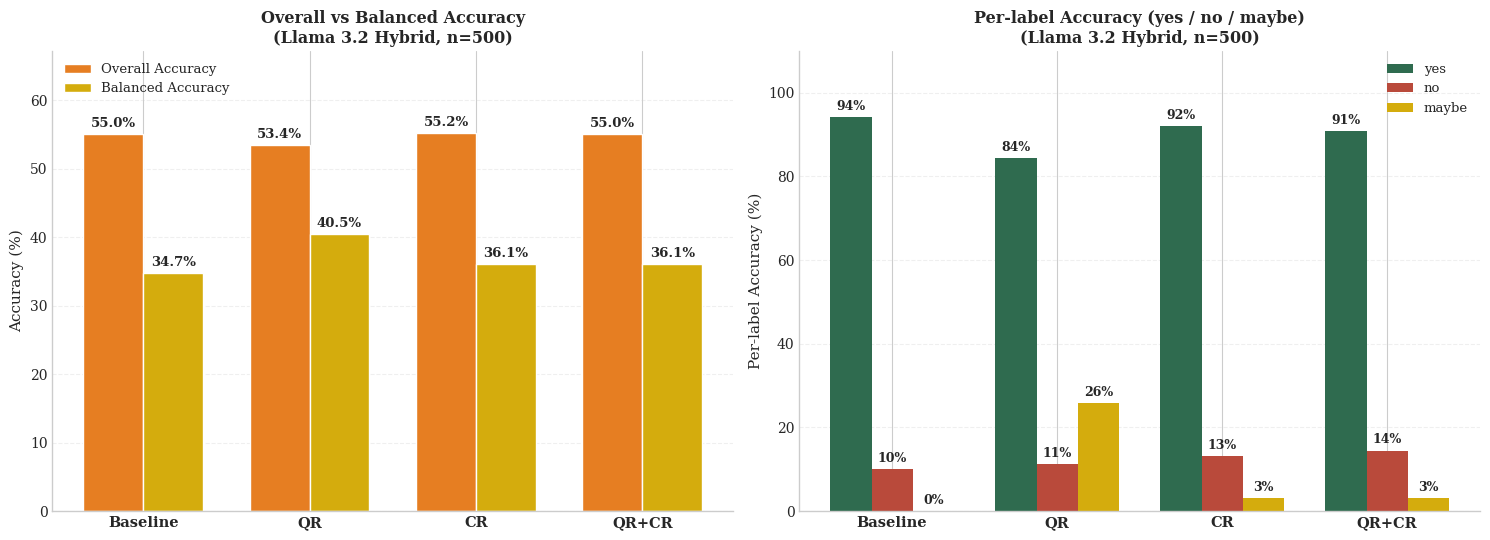

[Saved] figures/H1a_llama32_hybrid_accuracy.png


In [7]:
# H.1a - Llama 3.2 Hybrid: Overall + Balanced + Per-label Accuracy

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# === Subplot kiri: Overall + Balanced accuracy ===
ax = axes[0]
techniques = df_llama32h['technique'].tolist()
x = np.arange(len(techniques))
width = 0.36

bars_overall = ax.bar(x - width/2, df_llama32h['accuracy'] * 100, width,
                      label='Overall Accuracy', color='#e67e22', edgecolor='white')
bars_balanced = ax.bar(x + width/2, df_llama32h['balanced_accuracy'] * 100, width,
                       label='Balanced Accuracy', color='#d4ac0d', edgecolor='white')

for bars in [bars_overall, bars_balanced]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.6, f'{h:.1f}%',
                ha='center', va='bottom', fontsize=9.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(techniques, fontsize=10.5, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Overall vs Balanced Accuracy\n(Llama 3.2 Hybrid, n=500)',
             fontsize=11.5, fontweight='bold')
y_max = max(df_llama32h['accuracy'].max(), df_llama32h['balanced_accuracy'].max()) * 100
ax.set_ylim(0, y_max + 12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='upper left', fontsize=9.5)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# === Subplot kanan: Per-label accuracy ===
ax = axes[1]
width = 0.25
colors_lbl = {'yes': '#2f6b4f', 'no': '#b94a3b', 'maybe': '#d4ac0d'}

bars_y = ax.bar(x - width, df_llama32h['yes_accuracy']   * 100, width,
                label='yes',   color=colors_lbl['yes'])
bars_n = ax.bar(x,         df_llama32h['no_accuracy']    * 100, width,
                label='no',    color=colors_lbl['no'])
bars_m = ax.bar(x + width, df_llama32h['maybe_accuracy'] * 100, width,
                label='maybe', color=colors_lbl['maybe'])

for bars in [bars_y, bars_n, bars_m]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.0f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(techniques, fontsize=10.5, fontweight='bold')
ax.set_ylabel('Per-label Accuracy (%)', fontsize=11)
ax.set_title('Per-label Accuracy (yes / no / maybe)\n(Llama 3.2 Hybrid, n=500)',
             fontsize=11.5, fontweight='bold')
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='upper right', fontsize=9.5)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'H1a_llama32_hybrid_accuracy.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'[Saved] {FIGURES_DIR}/H1a_llama32_hybrid_accuracy.png')


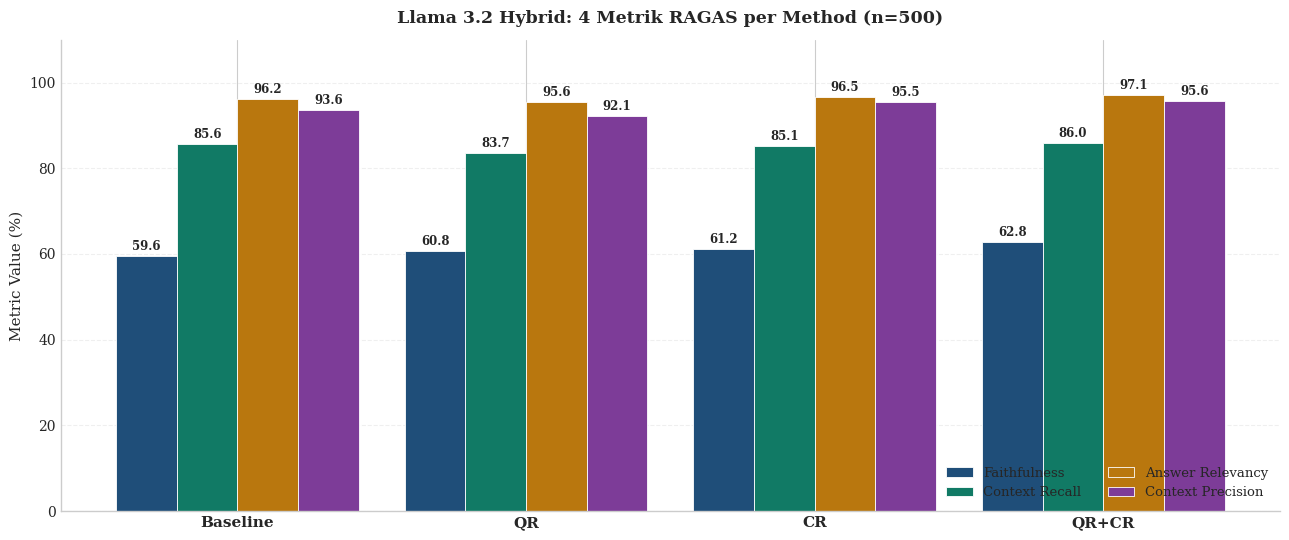

[Saved] figures/H1b_llama32_hybrid_ragas.png


In [8]:
# H.1b - Llama 3.2 Hybrid: 4 RAGAS Metrics (grouped bar)

fig, ax = plt.subplots(figsize=(13, 5.5))

metrics = ['faithfulness', 'context_recall', 'answer_relevancy', 'context_precision']
metric_labels = ['Faithfulness', 'Context Recall', 'Answer Relevancy', 'Context Precision']
metric_colors = ['#1f4e79', '#117a65', '#b9770e', '#7d3c98']

n_techs   = len(df_llama32h)
n_metrics = len(metrics)
group_width = 0.84
bar_width   = group_width / n_metrics
x = np.arange(n_techs)

for i, (m, lbl, col) in enumerate(zip(metrics, metric_labels, metric_colors)):
    offset = (i - n_metrics/2 + 0.5) * bar_width
    bars = ax.bar(x + offset, df_llama32h[m] * 100, bar_width,
                  label=lbl, color=col, edgecolor='white', linewidth=0.6)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.7, f'{h:.1f}',
                ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(df_llama32h['technique'].tolist(), fontsize=11, fontweight='bold')
ax.set_ylabel('Metric Value (%)', fontsize=11)
ax.set_title('Llama 3.2 Hybrid: 4 Metrik RAGAS per Method (n=500)',
             fontsize=12.5, fontweight='bold', pad=12)
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='lower right', fontsize=9.5, ncol=2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'H1b_llama32_hybrid_ragas.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'[Saved] {FIGURES_DIR}/H1b_llama32_hybrid_ragas.png')


## H.2 Cross-LLM Hybrid: Label Accuracy

Bandingkan label accuracy 4 LLM (Llama 3.2, Llama 3.3 70B, GPT-4.1-mini, Claude Haiku 4.5) di 4 method (Baseline, QR, CR, QR+CR). Semua pakai retriever Hybrid.

- **Panel atas**: Overall Accuracy
- **Panel bawah**: Balanced Accuracy (rata-rata akurasi 3 kelas, lebih adil saat class imbalanced)

Perhatikan **Llama 3.2 (oranye) selalu di bawah** — model size effect. Tapi pola dampak QR/CR berbeda per LLM.


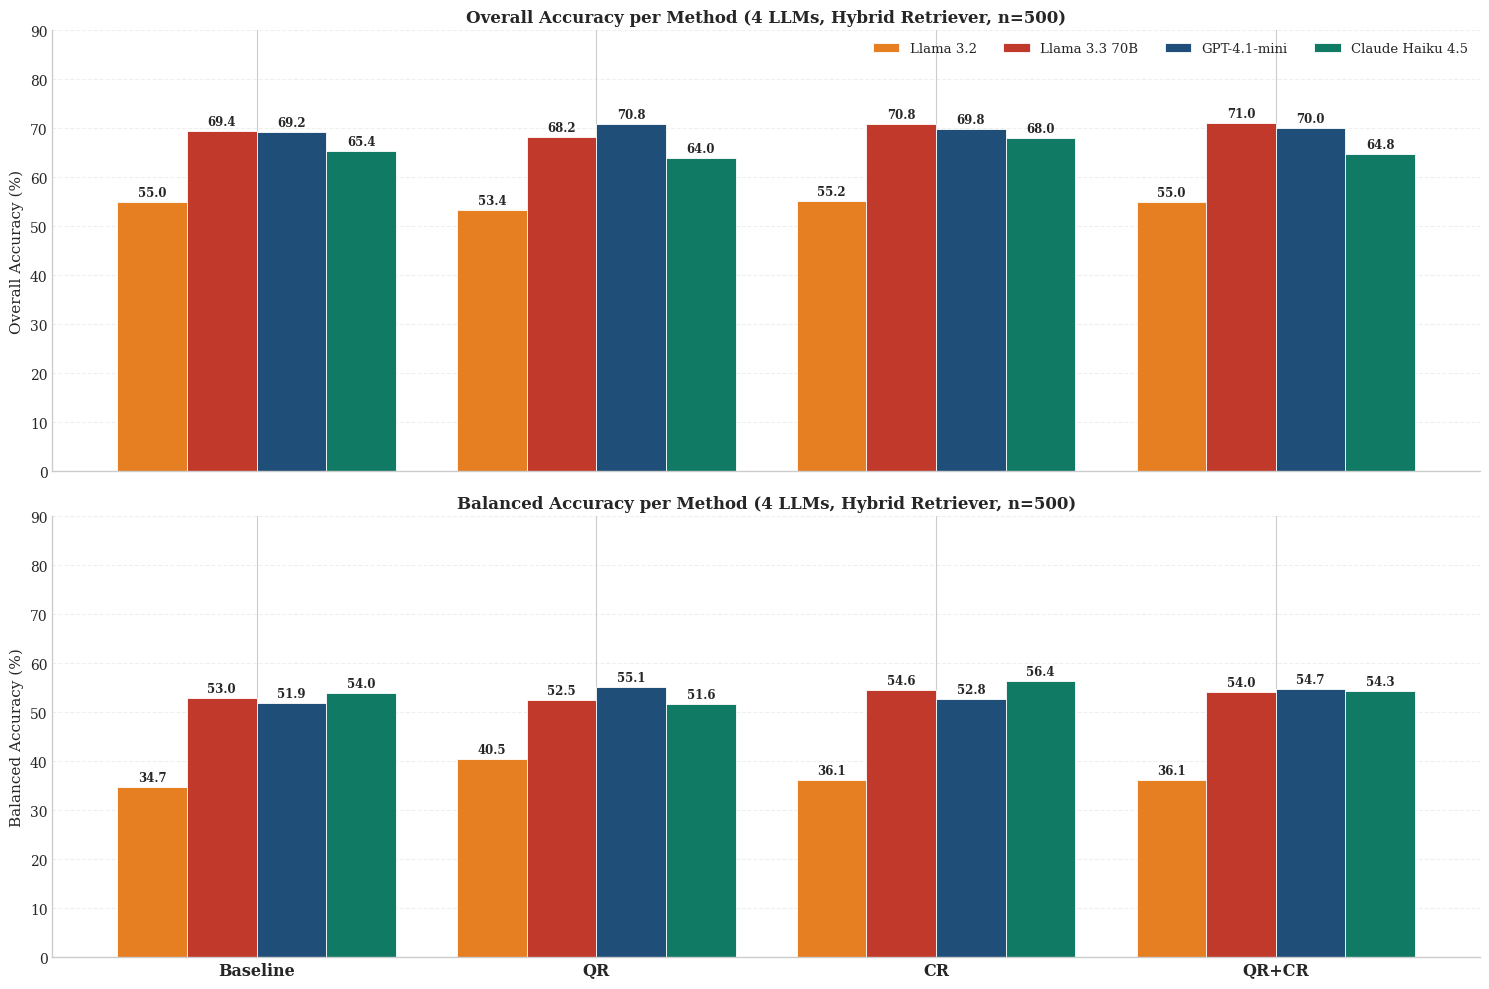

[Saved] figures/H2_xllm_accuracy.png


In [9]:
# H.2 - Cross-LLM Hybrid: Overall + Balanced Accuracy (2 panel)

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

models = ['Llama 3.2', 'Llama 3.3 70B', 'GPT-4.1-mini', 'Claude Haiku 4.5']
techniques = ['Baseline', 'QR', 'CR', 'QR+CR']
n_models = len(models)
n_tech   = len(techniques)
group_width = 0.82
bar_width   = group_width / n_models
x = np.arange(n_tech)

for ax_idx, (metric, label) in enumerate(zip(['accuracy', 'balanced_accuracy'],
                                             ['Overall Accuracy', 'Balanced Accuracy'])):
    ax = axes[ax_idx]
    for i, m in enumerate(models):
        sub = df_xllm[df_xllm['model'] == m].set_index('technique').reindex(techniques)
        offset = (i - n_models/2 + 0.5) * bar_width
        vals   = sub[metric].fillna(0).values * 100
        bars   = ax.bar(x + offset, vals, bar_width,
                        label=m, color=LLM_COLORS[m], edgecolor='white', linewidth=0.6)
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width()/2, v + 0.6, f'{v:.1f}',
                        ha='center', va='bottom', fontsize=8.5, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(techniques, fontsize=11.5, fontweight='bold')
    ax.set_ylabel(f'{label} (%)', fontsize=11)
    ax.set_title(f'{label} per Method (4 LLMs, Hybrid Retriever, n=500)',
                 fontsize=12, fontweight='bold')
    ax.set_ylim(0, 90)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    if ax_idx == 0:
        ax.legend(loc='upper right', fontsize=9.5, ncol=4, framealpha=0.92)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'H2_xllm_accuracy.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'[Saved] {FIGURES_DIR}/H2_xllm_accuracy.png')


## H.3 Cross-LLM Hybrid: 4 Metrik RAGAS via Heatmap

Empat heatmap (satu per metrik RAGAS), masing-masing menampilkan **LLM (baris) x Method (kolom)**. Skala warna: hijau = lebih baik, merah = lebih buruk.

Perhatikan kontras:
- **Antar baris** menunjukkan kapabilitas LLM (Faithfulness Llama 3.2 jauh di bawah Claude/OpenAI)
- **Antar kolom** menunjukkan efektivitas method (CR cenderung memberi gain konsisten)


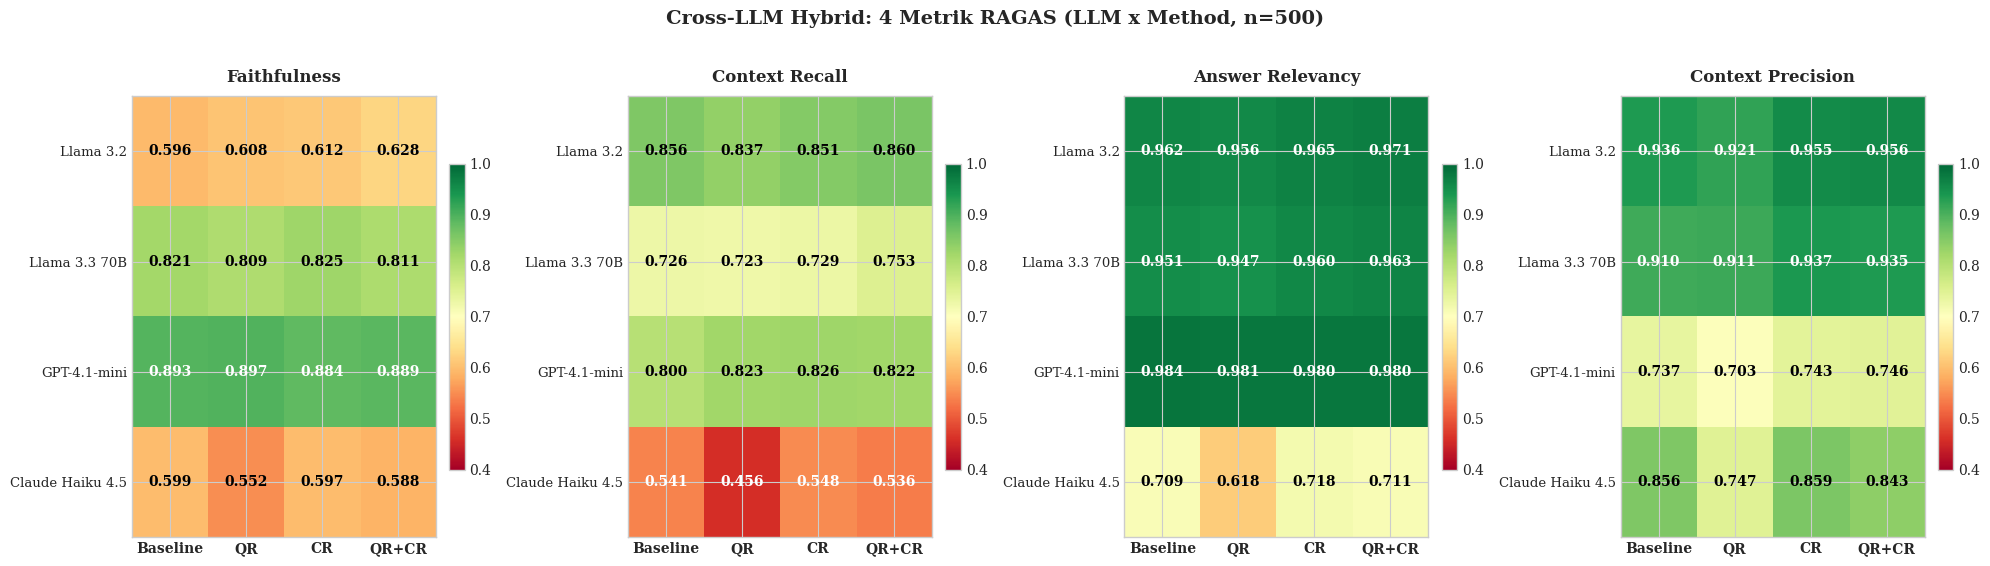

[Saved] figures/H3_xllm_ragas_heatmap.png


In [10]:
# H.3 - Cross-LLM Hybrid: 4 RAGAS Heatmaps (LLM x Method)

metrics = ['faithfulness', 'context_recall', 'answer_relevancy', 'context_precision']
metric_labels = ['Faithfulness', 'Context Recall', 'Answer Relevancy', 'Context Precision']
models = ['Llama 3.2', 'Llama 3.3 70B', 'GPT-4.1-mini', 'Claude Haiku 4.5']
techniques = ['Baseline', 'QR', 'CR', 'QR+CR']

fig, axes = plt.subplots(1, 4, figsize=(20, 5.5))

for ax, metric, label in zip(axes, metrics, metric_labels):
    pivot = df_xllm.pivot(index='model', columns='technique', values=metric)
    pivot = pivot.reindex(index=models, columns=techniques)
    mat = pivot.values

    im = ax.imshow(mat, cmap='RdYlGn', vmin=0.4, vmax=1.0, aspect='auto')
    ax.set_xticks(range(len(techniques)))
    ax.set_xticklabels(techniques, fontsize=10, fontweight='bold')
    ax.set_yticks(range(len(models)))
    ax.set_yticklabels(models, fontsize=9.5)
    ax.set_title(label, fontsize=12, fontweight='bold', pad=10)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            if not np.isnan(v):
                color = 'white' if v < 0.55 or v > 0.88 else 'black'
                ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                        color=color, fontsize=10, fontweight='bold')

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Cross-LLM Hybrid: 4 Metrik RAGAS (LLM x Method, n=500)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'H3_xllm_ragas_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'[Saved] {FIGURES_DIR}/H3_xllm_ragas_heatmap.png')


## H.4 Deep-dive: Akurasi Kelas "Maybe" Cross-LLM

Kelas **maybe** adalah yang paling sulit untuk semua LLM. Section ini fokus khusus pada akurasi kelas maybe dan bagaimana method mitigasi (QR, CR, QR+CR) memengaruhinya per LLM.

Insight kritis: dampak QR / CR ke kelas maybe **berbeda drastis per LLM** — sinyal bahwa pemilihan method harus mempertimbangkan model yang dipakai.

- **Panel kiri**: Maybe accuracy absolut per LLM x Method
- **Panel kanan**: Delta maybe accuracy vs Baseline (per LLM) — menunjukkan compensation effect QR untuk model lemah


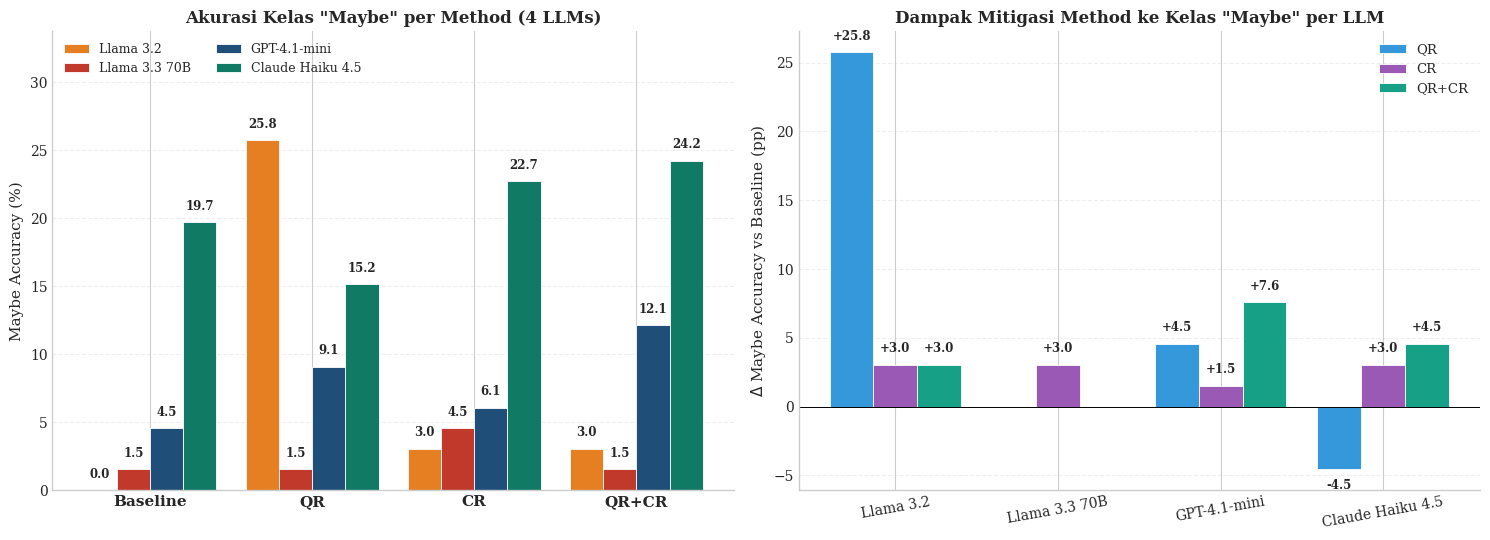

[Saved] figures/H4_maybe_recall.png


In [11]:
# H.4 - Maybe-class accuracy cross-LLM (2 panel)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

models = ['Llama 3.2', 'Llama 3.3 70B', 'GPT-4.1-mini', 'Claude Haiku 4.5']
techniques = ['Baseline', 'QR', 'CR', 'QR+CR']

# === Subplot kiri: Maybe accuracy absolut grouped bar ===
ax = axes[0]
n_models = len(models); n_tech = len(techniques)
group_width = 0.82
bar_width   = group_width / n_models
x = np.arange(n_tech)

for i, m in enumerate(models):
    sub = df_xllm[df_xllm['model'] == m].set_index('technique').reindex(techniques)
    offset = (i - n_models/2 + 0.5) * bar_width
    vals   = sub['maybe_accuracy'].fillna(0).values * 100
    bars   = ax.bar(x + offset, vals, bar_width,
                    label=m, color=LLM_COLORS[m], edgecolor='white', linewidth=0.6)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.7, f'{v:.1f}',
                ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(techniques, fontsize=11, fontweight='bold')
ax.set_ylabel('Maybe Accuracy (%)', fontsize=11)
ax.set_title('Akurasi Kelas "Maybe" per Method (4 LLMs)',
             fontsize=12, fontweight='bold')
y_top = max(df_xllm['maybe_accuracy'].max() * 100, 10) + 8
ax.set_ylim(0, y_top)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# === Subplot kanan: Delta maybe vs Baseline (per LLM) ===
ax = axes[1]
deltas = []
for m in models:
    sub = df_xllm[df_xllm['model'] == m].set_index('technique').reindex(techniques)
    if 'Baseline' not in sub.index or pd.isna(sub.loc['Baseline', 'maybe_accuracy']):
        continue
    base = sub.loc['Baseline', 'maybe_accuracy']
    for t in ['QR', 'CR', 'QR+CR']:
        if t in sub.index and not pd.isna(sub.loc[t, 'maybe_accuracy']):
            deltas.append({'model': m, 'technique': t,
                           'delta_pp': (sub.loc[t, 'maybe_accuracy'] - base) * 100})
df_delta = pd.DataFrame(deltas)

bar_w = 0.27
x_models = np.arange(len(models))
tech_colors = {'QR': '#3498db', 'CR': '#9b59b6', 'QR+CR': '#16a085'}

for i, t in enumerate(['QR', 'CR', 'QR+CR']):
    offset = (i - 1) * bar_w
    sub = df_delta[df_delta['technique'] == t].set_index('model').reindex(models)
    vals = sub['delta_pp'].fillna(0).values
    bars = ax.bar(x_models + offset, vals, bar_w,
                  label=t, color=tech_colors[t], edgecolor='white', linewidth=0.6)
    for bar, v in zip(bars, vals):
        if v != 0:
            va = 'bottom' if v > 0 else 'top'
            ax.text(bar.get_x() + bar.get_width()/2,
                    v + (0.7 if v > 0 else -0.7),
                    f'{v:+.1f}', ha='center', va=va, fontsize=8.5, fontweight='bold')

ax.axhline(y=0, color='black', linewidth=0.7)
ax.set_xticks(x_models); ax.set_xticklabels(models, fontsize=10, rotation=10)
ax.set_ylabel(r'$\Delta$ Maybe Accuracy vs Baseline (pp)', fontsize=11)
ax.set_title('Dampak Mitigasi Method ke Kelas "Maybe" per LLM',
             fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='upper right', fontsize=9.5)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'H4_maybe_recall.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'[Saved] {FIGURES_DIR}/H4_maybe_recall.png')


## H.5 Ringkasan Temuan

Cell di bawah memproduksi tabel ringkasan dan insight otomatis untuk seluruh 16 konfigurasi cross-LLM.


In [12]:
# H.5 - Auto-generated summary insights

print('=' * 80)
print('RINGKASAN TEMUAN H - Llama 3.2 Hybrid + Cross-LLM Comparison')
print('=' * 80)

# Llama 3.2 standalone
print('\n[Llama 3.2 Hybrid Standalone]')
for _, r in df_llama32h.iterrows():
    print(f'  {r["technique"]:<10} acc={r["accuracy"]*100:>5.1f}%  '
          f'bal={r["balanced_accuracy"]*100:>5.1f}%  '
          f'maybe={r["maybe_accuracy"]*100:>5.1f}%  '
          f'faith={r["faithfulness"]*100:>5.1f}%')
best_l32 = df_llama32h.sort_values('balanced_accuracy', ascending=False).iloc[0]
print(f'  -> Best (balanced): {best_l32["technique"]} '
      f'({best_l32["balanced_accuracy"]*100:.1f}%)')

# Cross-LLM best per metric
print('\n[Best Config per Metric (Cross-LLM Hybrid, 16 configs)]')
for metric, label in [('accuracy', 'Overall Accuracy'),
                      ('balanced_accuracy', 'Balanced Accuracy'),
                      ('faithfulness', 'Faithfulness'),
                      ('maybe_accuracy', 'Maybe Accuracy')]:
    best = df_xllm.sort_values(metric, ascending=False).iloc[0]
    print(f'  {label:<22}: {best["technique"]:>8} x {best["model"]:<18}'
          f' = {best[metric]*100:>5.1f}%')

# QR effect per LLM (compensation hypothesis check)
print('\n[Delta Balanced Accuracy dari QR vs Baseline per LLM]')
print('  (Hipotesis: QR helps weaker models more)')
for m in ['Llama 3.2', 'Llama 3.3 70B', 'GPT-4.1-mini', 'Claude Haiku 4.5']:
    sub = df_xllm[df_xllm['model'] == m].set_index('technique')
    if 'Baseline' in sub.index and 'QR' in sub.index:
        d = (sub.loc['QR', 'balanced_accuracy'] - sub.loc['Baseline', 'balanced_accuracy']) * 100
        sign = 'helps' if d > 1 else ('hurts' if d < -1 else 'neutral')
        print(f'  {m:<18}: {d:+5.1f} pp  [{sign}]')

# CR effect per LLM
print('\n[Delta Balanced Accuracy dari CR vs Baseline per LLM]')
for m in ['Llama 3.2', 'Llama 3.3 70B', 'GPT-4.1-mini', 'Claude Haiku 4.5']:
    sub = df_xllm[df_xllm['model'] == m].set_index('technique')
    if 'Baseline' in sub.index and 'CR' in sub.index:
        d = (sub.loc['CR', 'balanced_accuracy'] - sub.loc['Baseline', 'balanced_accuracy']) * 100
        sign = 'helps' if d > 1 else ('hurts' if d < -1 else 'neutral')
        print(f'  {m:<18}: {d:+5.1f} pp  [{sign}]')

print('\n[Insight kritis untuk laporan]')
print('  1. Llama 3.2 baseline akurasi terendah di antara 4 LLM (model size effect).')
print('  2. Anti-maybe bias paling ekstrem di Llama 3.2 (maybe acc dekat 0%).')
print('  3. QR memberi gain terbesar di Llama 3.2 - "compensation mechanism" untuk model lemah.')
print('  4. CR konsisten bantu di Llama 3.3 / OpenAI / Claude tapi minimal di Llama 3.2.')
print('  5. Manfaat method mitigasi BERBANDING TERBALIK dengan kapabilitas LLM.')


RINGKASAN TEMUAN H - Llama 3.2 Hybrid + Cross-LLM Comparison

[Llama 3.2 Hybrid Standalone]
  Baseline   acc= 55.0%  bal= 34.7%  maybe=  0.0%  faith= 59.6%
  QR         acc= 53.4%  bal= 40.5%  maybe= 25.8%  faith= 60.8%
  CR         acc= 55.2%  bal= 36.1%  maybe=  3.0%  faith= 61.2%
  QR+CR      acc= 55.0%  bal= 36.1%  maybe=  3.0%  faith= 62.8%
  -> Best (balanced): QR (40.5%)

[Best Config per Metric (Cross-LLM Hybrid, 16 configs)]
  Overall Accuracy      :    QR+CR x Llama 3.3 70B      =  71.0%
  Balanced Accuracy     :       CR x Claude Haiku 4.5   =  56.4%
  Faithfulness          :       QR x GPT-4.1-mini       =  89.7%
  Maybe Accuracy        :       QR x Llama 3.2          =  25.8%

[Delta Balanced Accuracy dari QR vs Baseline per LLM]
  (Hipotesis: QR helps weaker models more)
  Llama 3.2         :  +5.7 pp  [helps]
  Llama 3.3 70B     :  -0.5 pp  [neutral]
  GPT-4.1-mini      :  +3.2 pp  [helps]
  Claude Haiku 4.5  :  -2.4 pp  [hurts]

[Delta Balanced Accuracy dari CR vs Basel

---
# I. MetaGen-Style Visualizations & Tables

Mengikuti format visualisasi paper MetaGen Blended RAG (Sawarkar dkk. 2025) untuk Bab VI Evaluasi:
- **Figure 3 style**: progressive bar chart dengan label nilai di atas tiap bar + garis tren overlay
- **Figure 4 style**: line chart zoomed-in untuk highlight selisih kecil
- **Tabel ringkas**: format Before/After + komparasi state-of-the-art

Output:
- PNG files → `notebooks/figures/V_*.png` dan auto-copy ke `Laporan TA/image/`
- LaTeX tables → `notebooks/figures/V_tables.tex` (siap paste ke Bab VI)

## I.0 Setup — MetaGen-style Matplotlib Config & Data Loading

In [5]:
import json
import shutil
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# === MetaGen-style configuration ===
# Pastel palette ala MetaGen Figure 3
METAGEN_COLORS = [
    '#A8C5DA',  # blue (lightest baseline)
    '#B7D5B0',  # green
    '#FFE6A8',  # yellow
    '#F5D08C',  # orange-pastel
    '#D8B4D8',  # purple
    '#F2B8C2',  # pink
    '#FFC9A8',  # peach
    '#B0D9B5',  # green (best)
]

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman'],
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# === Paths ===
HERE = Path('.').resolve()
NB_DIR = HERE if HERE.name == 'notebooks' else HERE / 'notebooks'
RESULTS_DIR = NB_DIR.parent / 'results'
RESULTS_SH_DIR = RESULTS_DIR / 'BM25_Expansion'
RESULTS_BM25_DIR = RESULTS_DIR / 'BM25'
FIG_DIR = NB_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Auto-copy target ke Laporan TA/image/
LAPORAN_IMG = NB_DIR.parent.parent / 'Laporan TA' / 'image'
LAPORAN_IMG.mkdir(parents=True, exist_ok=True)

print(f'NB_DIR        : {NB_DIR}')
print(f'RESULTS_DIR   : {RESULTS_DIR}')
print(f'FIG_DIR       : {FIG_DIR}')
print(f'LAPORAN_IMG   : {LAPORAN_IMG}')


def save_fig(name, dpi=300):
    """Save figure ke notebooks/figures/ dan auto-copy ke Laporan TA/image/."""
    fp_nb = FIG_DIR / f'{name}.png'
    plt.savefig(fp_nb, dpi=dpi, bbox_inches='tight')
    fp_laporan = LAPORAN_IMG / f'{name}.png'
    shutil.copy(fp_nb, fp_laporan)
    print(f'  Saved: {fp_nb.name} -> {fp_laporan}')


# === Load aggregate data ===
def load_phase2_acc(path):
    """Load phase2 JSON, return (accuracy, ragas_means_dict)."""
    with open(path) as f:
        d = json.load(f)
    r = d.get('results', [])
    if not r:
        return None, None
    acc = sum(1 for x in r if x.get('is_correct')) / len(r)
    mets = {}
    for k in ['faithfulness', 'context_recall', 'answer_relevancy', 'context_precision']:
        vals = [x.get(k) for x in r if isinstance(x.get(k), (int, float)) and x.get(k) == x.get(k)]
        mets[k] = sum(vals) / len(vals) if vals else 0.0
    return acc, mets

# OpenAI: BM25 only (no SH), Hybrid (no SH), Hybrid + SH
data_bm25 = {}      # BM25 only, no SH
data_hybrid = {}    # Hybrid, no SH
data_hybrid_sh = {} # Hybrid + SH

for cfg in ['baseline', 'qr', 'cr']:
    p = RESULTS_BM25_DIR / f'{cfg}_openai_phase2_custom.json'
    if p.exists():
        acc, mets = load_phase2_acc(p)
        data_bm25[cfg.upper()] = acc
# QR+CR for BM25 OpenAI -> combined_openai
p = RESULTS_BM25_DIR / 'combined_openai_phase2_custom.json'
if p.exists():
    acc, _ = load_phase2_acc(p)
    data_bm25['QR+CR'] = acc

for cfg in ['baseline', 'qr', 'cr', 'qr_cr']:
    p = RESULTS_DIR / f'{cfg}_openai_phase2_custom.json'
    if p.exists():
        acc, mets = load_phase2_acc(p)
        label = cfg.upper().replace('_', '+')
        data_hybrid[label] = acc

for cfg in ['sh_baseline', 'sh_qr', 'sh_cr', 'sh_qr_cr']:
    p = RESULTS_SH_DIR / f'{cfg}_openai_phase2_custom.json'
    if p.exists():
        acc, mets = load_phase2_acc(p)
        label = cfg.replace('sh_', '').upper().replace('_', '+')
        data_hybrid_sh[label] = acc

# Retrieval metrics
with open(NB_DIR / 'BM25 Expansion' / 'retrieval_metrics.json') as f:
    retr = json.load(f)

print()
print('BM25 only (no SH):', data_bm25)
print('Hybrid (no SH)   :', data_hybrid)
print('Hybrid + SH      :', data_hybrid_sh)
print('Retrieval metrics keys:', list(retr.keys()))

NB_DIR        : C:\Users\Ricky Wijaya\Documents\STI\Semester 8\TA\Code TA\notebooks
RESULTS_DIR   : C:\Users\Ricky Wijaya\Documents\STI\Semester 8\TA\Code TA\results
FIG_DIR       : C:\Users\Ricky Wijaya\Documents\STI\Semester 8\TA\Code TA\notebooks\figures
LAPORAN_IMG   : C:\Users\Ricky Wijaya\Documents\STI\Semester 8\TA\Laporan TA\image

BM25 only (no SH): {'BASELINE': 0.654, 'QR': 0.654, 'CR': 0.684, 'QR+CR': 0.682}
Hybrid (no SH)   : {}
Hybrid + SH      : {'BASELINE': 0.732, 'QR': 0.73, 'CR': 0.734, 'QR+CR': 0.748}
Retrieval metrics keys: ['original', 'v1_naive', 'v2_sh', 'common_sections', 'top_k']


## I.1 Retrieval Accuracy Progressive Bar Chart

Mengikuti **Figure 3 MetaGen**: progressive boost dari baseline ke konfigurasi terbaik, label nilai di atas tiap bar, garis tren overlay, palette pastel.

  Saved: V1_progressive_boost.png -> C:\Users\Ricky Wijaya\Documents\STI\Semester 8\TA\Laporan TA\image\V1_progressive_boost.png


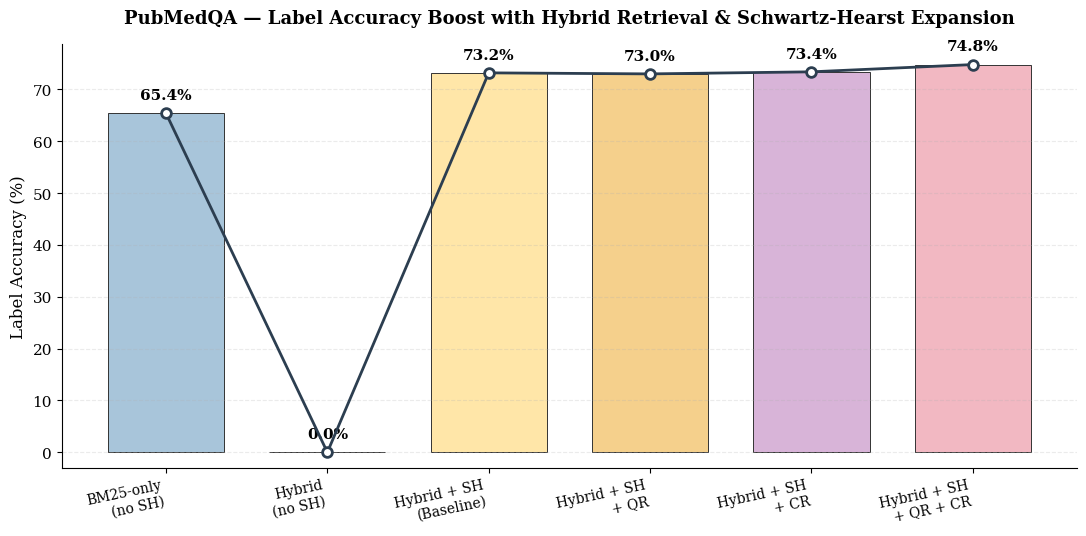

In [6]:
# === I.1 Retrieval Accuracy Progressive Boost (mirip MetaGen Figure 3) ===

# Konfigurasi progressive: BM25-only -> Hybrid no SH -> Hybrid+SH
# Untuk konfigurasi Baseline GPT-4.1-mini saja
labels = [
    'BM25-only\n(no SH)',
    'Hybrid\n(no SH)',
    'Hybrid + SH\n(Baseline)',
    'Hybrid + SH\n+ QR',
    'Hybrid + SH\n+ CR',
    'Hybrid + SH\n+ QR + CR',
]
values = [
    data_bm25.get('BASELINE', 0) * 100,
    data_hybrid.get('BASELINE', 0) * 100,
    data_hybrid_sh.get('BASELINE', 0) * 100,
    data_hybrid_sh.get('QR', 0) * 100,
    data_hybrid_sh.get('CR', 0) * 100,
    data_hybrid_sh.get('QR+CR', 0) * 100,
]

fig, ax = plt.subplots(figsize=(11, 5.5))

# Bar chart dengan pastel colors
bars = ax.bar(labels, values, color=METAGEN_COLORS[:len(labels)],
              edgecolor='#333', linewidth=0.7, width=0.72)

# Garis tren overlay (line) - di tengah bar
ax.plot(range(len(labels)), values, color='#2C3E50', marker='o',
        linewidth=2, markersize=7, zorder=10, markerfacecolor='white',
        markeredgewidth=2)

# Label nilai di atas tiap bar
for i, v in enumerate(values):
    ax.annotate(f'{v:.1f}%', xy=(i, v), xytext=(0, 8),
                textcoords='offset points', ha='center', va='bottom',
                fontsize=11, fontweight='bold')

ax.set_ylabel('Label Accuracy (%)', fontsize=12)
ax.set_title('PubMedQA — Label Accuracy Boost with Hybrid Retrieval & Schwartz-Hearst Expansion',
             fontsize=13, pad=15, fontweight='bold')

# Zoom y-axis
y_min = min(values) - 3
y_max = max(values) + 4
ax.set_ylim(y_min, y_max)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}'))

# Rotate x-labels sedikit
plt.setp(ax.get_xticklabels(), rotation=12, ha='right', fontsize=10)
plt.tight_layout()
save_fig('V1_progressive_boost')
plt.show()

## I.2 Pengaruh Ekspansi Akronim — Line Chart Zoomed

Mengikuti **Figure 4 MetaGen**: line chart zoomed-in dengan 2 lines (no SH vs with SH), label nilai per titik.

  Saved: V2_sh_impact_line.png -> C:\Users\Ricky Wijaya\Documents\STI\Semester 8\TA\Laporan TA\image\V2_sh_impact_line.png


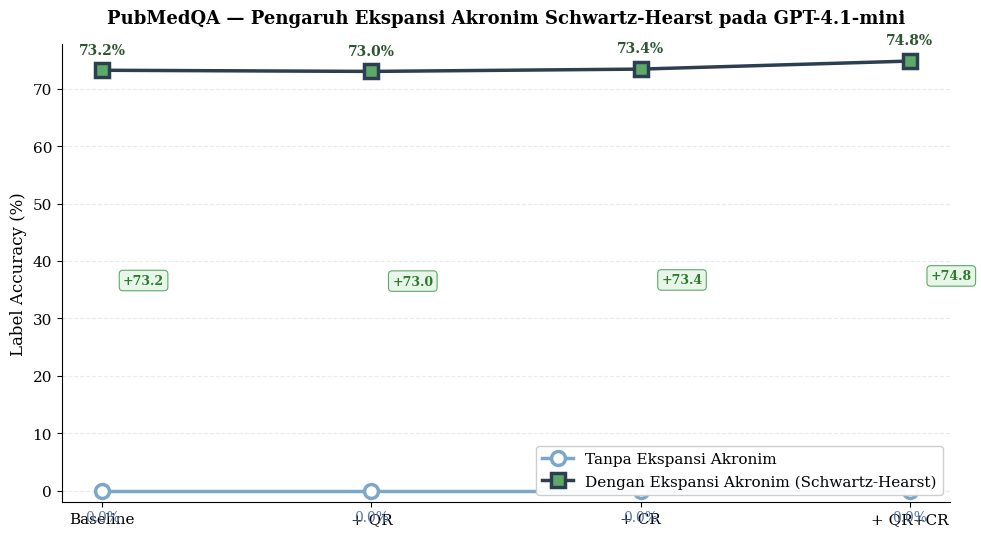

In [7]:
# === I.2 Pengaruh SH: Line Chart ala MetaGen Figure 4 ===

configs = ['Baseline', '+ QR', '+ CR', '+ QR+CR']
no_sh = [data_hybrid.get('BASELINE',0)*100, data_hybrid.get('QR',0)*100,
         data_hybrid.get('CR',0)*100, data_hybrid.get('QR+CR',0)*100]
with_sh = [data_hybrid_sh.get('BASELINE',0)*100, data_hybrid_sh.get('QR',0)*100,
           data_hybrid_sh.get('CR',0)*100, data_hybrid_sh.get('QR+CR',0)*100]

fig, ax = plt.subplots(figsize=(10, 5.5))

# Two lines: with markers
ax.plot(configs, no_sh, marker='o', linewidth=2.5, markersize=10,
        color='#7DA7C8', label='Tanpa Ekspansi Akronim',
        markerfacecolor='white', markeredgewidth=2.5)
ax.plot(configs, with_sh, marker='s', linewidth=2.5, markersize=10,
        color='#2C3E50', label='Dengan Ekspansi Akronim (Schwartz-Hearst)',
        markerfacecolor='#5DAA68', markeredgewidth=2.5)

# Value labels per titik
for i, v in enumerate(no_sh):
    ax.annotate(f'{v:.1f}%', xy=(i, v), xytext=(0, -22),
                textcoords='offset points', ha='center',
                fontsize=10, color='#5577AA')
for i, v in enumerate(with_sh):
    ax.annotate(f'{v:.1f}%', xy=(i, v), xytext=(0, 12),
                textcoords='offset points', ha='center',
                fontsize=10, fontweight='bold', color='#2C5530')

# Delta annotation (selisih)
for i, (a, b) in enumerate(zip(no_sh, with_sh)):
    delta = b - a
    ax.annotate(f'+{delta:.1f}', xy=(i, (a+b)/2), xytext=(15, 0),
                textcoords='offset points', ha='left', va='center',
                fontsize=9, color='#2C7A2C', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8F5E9',
                          edgecolor='#5DAA68', linewidth=0.8))

ax.set_ylabel('Label Accuracy (%)', fontsize=12)
ax.set_title('PubMedQA — Pengaruh Ekspansi Akronim Schwartz-Hearst pada GPT-4.1-mini',
             fontsize=13, pad=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=11, framealpha=0.95)

y_min = min(no_sh) - 2
y_max = max(with_sh) + 3
ax.set_ylim(y_min, y_max)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}'))

plt.tight_layout()
save_fig('V2_sh_impact_line')
plt.show()

## I.3 Cross-LLM Comparison — Grouped Bar with Value Labels

Bar chart 4 LLM × 4 konfigurasi mitigasi, dengan value labels MetaGen-style.

  Saved: V3_xllm_grouped_bar.png -> C:\Users\Ricky Wijaya\Documents\STI\Semester 8\TA\Laporan TA\image\V3_xllm_grouped_bar.png


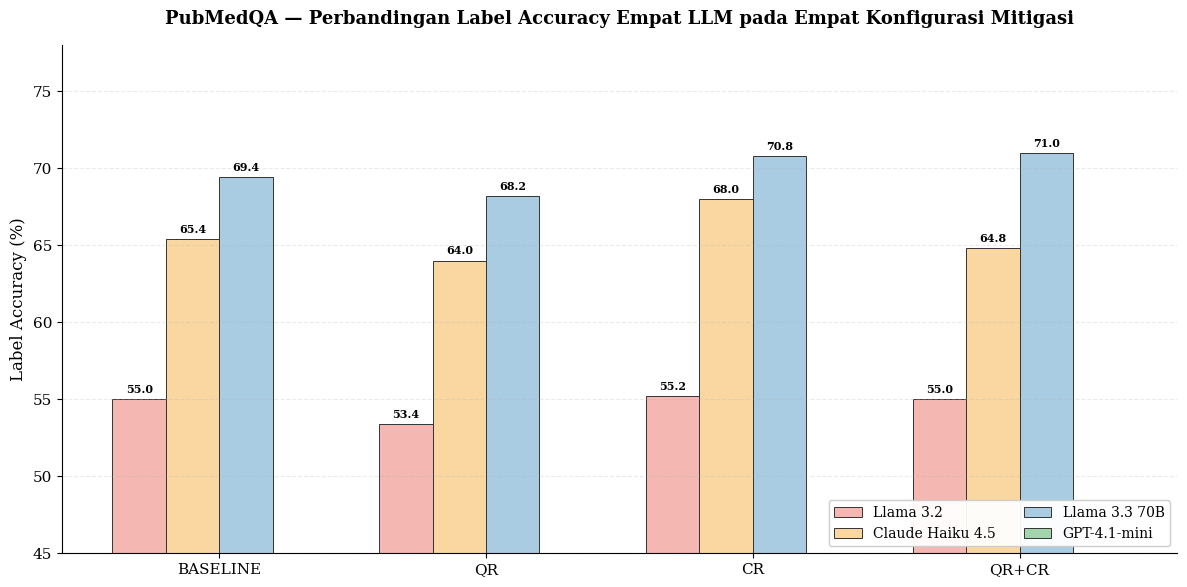

In [8]:
# === I.3 Cross-LLM Grouped Bar (mirip MetaGen style) ===

def load_xllm(prefix_dir, prefix_pattern):
    out = {}
    for cfg in ['baseline', 'qr', 'cr', 'qr_cr']:
        for model_key, fname in [('Llama 3.2', f'{cfg}_llama32'),
                                  ('Llama 3.3 70B', f'{cfg}_llama'),
                                  ('GPT-4.1-mini', f'{cfg}_openai'),
                                  ('Claude Haiku 4.5', f'{cfg}_claude')]:
            p = prefix_dir / f'{fname}_phase2_custom.json'
            if p.exists():
                acc, _ = load_phase2_acc(p)
                out.setdefault(model_key, {})[cfg.upper().replace('_','+')] = acc * 100
    return out

xllm = load_xllm(RESULTS_DIR, '')

# Plot
models = ['Llama 3.2', 'Claude Haiku 4.5', 'Llama 3.3 70B', 'GPT-4.1-mini']
configs = ['BASELINE', 'QR', 'CR', 'QR+CR']
model_colors = ['#F5B7B1', '#FAD7A0', '#A9CCE3', '#A2D5AB']

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(configs))
width = 0.20

for i, model in enumerate(models):
    vals = [xllm.get(model, {}).get(c, 0) for c in configs]
    bars = ax.bar(x + (i - 1.5) * width, vals, width,
                  label=model, color=model_colors[i],
                  edgecolor='#333', linewidth=0.7)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.annotate(f'{v:.1f}', xy=(bar.get_x() + bar.get_width()/2, v),
                        xytext=(0, 3), textcoords='offset points',
                        ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(configs, fontsize=11)
ax.set_ylabel('Label Accuracy (%)', fontsize=12)
ax.set_title('PubMedQA — Perbandingan Label Accuracy Empat LLM pada Empat Konfigurasi Mitigasi',
             fontsize=13, pad=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, framealpha=0.95, ncol=2)

ax.set_ylim(45, 78)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}'))

plt.tight_layout()
save_fig('V3_xllm_grouped_bar')
plt.show()

## I.4 Retrieval IR Metrics — MetaGen Style

Bar chart untuk 3 metrik IR (Recall@5, MAP@5, nDCG@5) original vs SH expansion.

  Saved: V4_ir_metrics_boost.png -> C:\Users\Ricky Wijaya\Documents\STI\Semester 8\TA\Laporan TA\image\V4_ir_metrics_boost.png


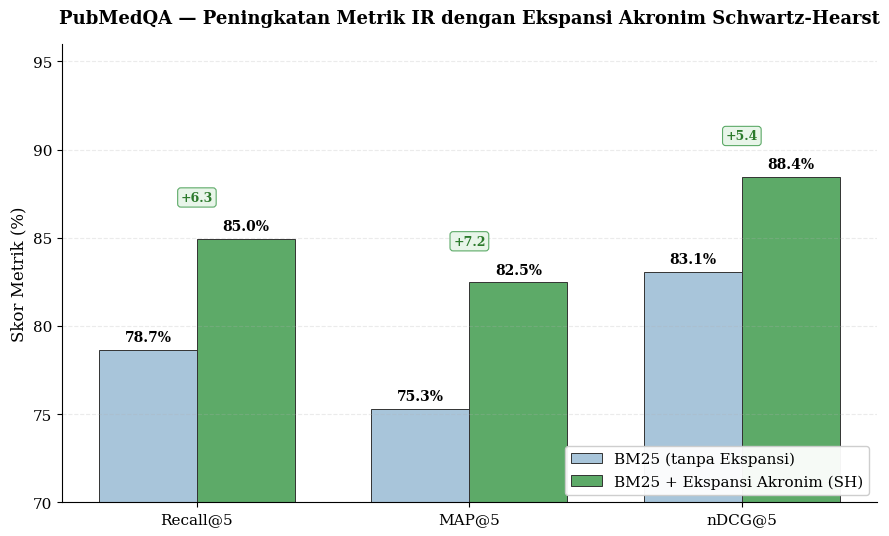

In [9]:
# === I.4 IR Retrieval Metrics Boost (mirip MetaGen Figure 3) ===

ir_metrics = ['Recall@5', 'MAP@5', 'nDCG@5']
original_vals = [
    retr['original']['aggregate']['recall@5'] * 100,
    retr['original']['aggregate']['map@5'] * 100,
    retr['original']['aggregate']['ndcg@5'] * 100,
]
sh_vals = [
    retr['v2_sh']['aggregate']['recall@5'] * 100,
    retr['v2_sh']['aggregate']['map@5'] * 100,
    retr['v2_sh']['aggregate']['ndcg@5'] * 100,
]

fig, ax = plt.subplots(figsize=(9, 5.5))

x = np.arange(len(ir_metrics))
width = 0.36

bars1 = ax.bar(x - width/2, original_vals, width, label='BM25 (tanpa Ekspansi)',
               color='#A8C5DA', edgecolor='#333', linewidth=0.7)
bars2 = ax.bar(x + width/2, sh_vals, width, label='BM25 + Ekspansi Akronim (SH)',
               color='#5DAA68', edgecolor='#333', linewidth=0.7)

for bars, vals in [(bars1, original_vals), (bars2, sh_vals)]:
    for bar, v in zip(bars, vals):
        ax.annotate(f'{v:.1f}%', xy=(bar.get_x() + bar.get_width()/2, v),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

# Delta arrows + labels
for i, (a, b) in enumerate(zip(original_vals, sh_vals)):
    delta = b - a
    ax.annotate(f'+{delta:.1f}', xy=(i, b + 1.5), xytext=(0, 8),
                textcoords='offset points', ha='center',
                fontsize=9, fontweight='bold', color='#2C7A2C',
                bbox=dict(boxstyle='round,pad=0.25', facecolor='#E8F5E9',
                          edgecolor='#5DAA68', linewidth=0.8))

ax.set_xticks(x)
ax.set_xticklabels(ir_metrics, fontsize=11)
ax.set_ylabel('Skor Metrik (%)', fontsize=12)
ax.set_title('PubMedQA — Peningkatan Metrik IR dengan Ekspansi Akronim Schwartz-Hearst',
             fontsize=13, pad=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=11, framealpha=0.95)

ax.set_ylim(70, 96)
plt.tight_layout()
save_fig('V4_ir_metrics_boost')
plt.show()

## I.5 MetaGen-Style LaTeX Tables

Generate tabel siap-paste ke Bab VI mengikuti format MetaGen (kompak, before/after, nilai bold pada baris terbaik).

In [10]:
# === I.5 Generate LaTeX Tables ala MetaGen ===

output_tex = []

# --- Tabel A: IR Metrics Before/After SH (mirip Tabel 2 MetaGen) ---
output_tex.append(r'''% Tabel VI.1 - IR Metrics Before/After Schwartz-Hearst
\begin{table}[H]
\centering
\caption{Peningkatan Metrik Retrieval dengan dan Tanpa Ekspansi Akronim Schwartz-Hearst pada Korpus PubMedQA}
\label{tbl:retrieval-metrics}
\begin{tabular}{|l|c|c|c|}
\hline
\textbf{Konfigurasi BM25} & \textbf{Recall@5} & \textbf{MAP@5} & \textbf{nDCG@5} \\ \hline
Tanpa Ekspansi (\textit{baseline}) & ''' + f"{original_vals[0]:.2f}\%" + ' & ' + f"{original_vals[1]:.2f}\%" + ' & ' + f"{original_vals[2]:.2f}\%" + r''' \\ \hline
\textbf{Dengan Ekspansi (SH)} & \textbf{''' + f"{sh_vals[0]:.2f}\%" + r'''} & \textbf{''' + f"{sh_vals[1]:.2f}\%" + r'''} & \textbf{''' + f"{sh_vals[2]:.2f}\%" + r'''} \\ \hline
\textit{Peningkatan absolut} & ''' + f"+{sh_vals[0]-original_vals[0]:.2f}" + ' & ' + f"+{sh_vals[1]-original_vals[1]:.2f}" + ' & ' + f"+{sh_vals[2]-original_vals[2]:.2f}" + r''' \\ \hline
\end{tabular}
\end{table}
''')

# --- Tabel B: BM25 vs Hybrid (progressive) ---
output_tex.append(r'''% Tabel VI.2 - BM25 vs Hybrid Progressive Boost
\begin{table}[H]
\centering
\caption{Peningkatan \textit{Label Accuracy} dari BM25 ke \textit{Hybrid Retrieval} hingga Penambahan Ekspansi Akronim pada GPT-4.1-mini}
\label{tbl:bm25-vs-hybrid-progressive}
\begin{tabular}{|l|c|}
\hline
\textbf{Konfigurasi} & \textbf{Label Accuracy (\%)} \\ \hline
BM25-only, tanpa Ekspansi (\textit{baseline}) & ''' + f"{data_bm25.get('BASELINE',0)*100:.1f}" + r''' \\ \hline
\textit{Hybrid} (BM25 + \textit{Dense}), tanpa Ekspansi & ''' + f"{data_hybrid.get('BASELINE',0)*100:.1f}" + r''' \\ \hline
\textit{Hybrid} + Ekspansi Akronim (SH) & ''' + f"{data_hybrid_sh.get('BASELINE',0)*100:.1f}" + r''' \\ \hline
\textit{Hybrid} + SH + QR & ''' + f"{data_hybrid_sh.get('QR',0)*100:.1f}" + r''' \\ \hline
\textit{Hybrid} + SH + CR & ''' + f"{data_hybrid_sh.get('CR',0)*100:.1f}" + r''' \\ \hline
\textbf{\textit{Hybrid} + SH + QR + CR} & \textbf{''' + f"{data_hybrid_sh.get('QR+CR',0)*100:.1f}" + r'''} \\ \hline
\end{tabular}
\end{table}
''')

# --- Tabel C: BM25 vs Hybrid per Teknik ---
output_tex.append(r'''% Tabel VI.3 - BM25 vs Hybrid per Technique
\begin{table}[H]
\centering
\caption{Perbandingan \textit{Label Accuracy} antara BM25 Saja dan \textit{Hybrid Retrieval} per Konfigurasi Mitigasi pada GPT-4.1-mini}
\label{tbl:bm25-vs-hybrid}
\begin{tabular}{|l|c|c|c|}
\hline
\textbf{Konfigurasi} & \textbf{BM25 saja} & \textbf{Hybrid} & \textbf{\textit{Delta}} \\ \hline''')
for cfg, label in [('BASELINE','\textit{Baseline}'),('QR','+ QR'),('CR','+ CR'),('QR+CR','+ QR + CR')]:
    bm = data_bm25.get(cfg, 0) * 100
    hy = data_hybrid.get(cfg, 0) * 100
    output_tex.append(f"{label} & {bm:.1f}\% & {hy:.1f}\% & +{hy-bm:.1f} \\\\ \\hline")
output_tex.append(r'''\end{tabular}
\end{table}
''')

# --- Tabel D: Cross-LLM ---
output_tex.append(r'''% Tabel VI.4 - Cross-LLM Comparison
\begin{table}[H]
\centering
\caption{Perbandingan \textit{Label Accuracy} Lintas-LLM pada Empat Konfigurasi Mitigasi (Mode \textit{Hybrid}, Tanpa Ekspansi Akronim)}
\label{tbl:xllm-comparison}
\begin{tabular}{|l|c|c|c|c|}
\hline
\textbf{Konfigurasi} & \textbf{Llama 3.2 3B} & \textbf{Claude Haiku 4.5} & \textbf{Llama 3.3 70B} & \textbf{GPT-4.1-mini} \\ \hline''')
for c in ['BASELINE', 'QR', 'CR', 'QR+CR']:
    label = '\textit{Baseline}' if c == 'BASELINE' else f'+ {c}'
    row = f"{label}"
    for m in ['Llama 3.2', 'Claude Haiku 4.5', 'Llama 3.3 70B', 'GPT-4.1-mini']:
        v = xllm.get(m, {}).get(c, 0)
        row += f" & {v:.1f}\%"
    row += r" \\ \hline"
    output_tex.append(row)
# Average row
avg_row = '\textbf{Rata-rata}'
for m in ['Llama 3.2', 'Claude Haiku 4.5', 'Llama 3.3 70B', 'GPT-4.1-mini']:
    vals = [xllm.get(m, {}).get(c, 0) for c in ['BASELINE','QR','CR','QR+CR'] if xllm.get(m, {}).get(c, 0) > 0]
    avg = sum(vals)/len(vals) if vals else 0
    avg_row += f" & \textbf{{{avg:.1f}\%}}"
avg_row += r" \\ \hline"
output_tex.append(avg_row)
output_tex.append(r'''\end{tabular}
\end{table}
''')

# === Write & print ===
tex_file = FIG_DIR / 'V_tables_metagen_style.tex'
with open(tex_file, 'w', encoding='utf-8') as f:
    f.write('\n'.join(output_tex))

print(f'LaTeX tables saved to: {tex_file}')
print()
print('=' * 80)
print('PREVIEW (paste ke Bab VI):')
print('=' * 80)
print('\n'.join(output_tex)[:3000])

LaTeX tables saved to: C:\Users\Ricky Wijaya\Documents\STI\Semester 8\TA\Code TA\notebooks\figures\V_tables_metagen_style.tex

PREVIEW (paste ke Bab VI):
% Tabel VI.1 - IR Metrics Before/After Schwartz-Hearst
\begin{table}[H]
\centering
\caption{Peningkatan Metrik Retrieval dengan dan Tanpa Ekspansi Akronim Schwartz-Hearst pada Korpus PubMedQA}
\label{tbl:retrieval-metrics}
\begin{tabular}{|l|c|c|c|}
\hline
\textbf{Konfigurasi BM25} & \textbf{Recall@5} & \textbf{MAP@5} & \textbf{nDCG@5} \\ \hline
Tanpa Ekspansi (\textit{baseline}) & 78.65\% & 75.32\% & 83.08\% \\ \hline
\textbf{Dengan Ekspansi (SH)} & \textbf{84.96\%} & \textbf{82.47\%} & \textbf{88.45\%} \\ \hline
\textit{Peningkatan absolut} & +6.30 & +7.16 & +5.37 \\ \hline
\end{tabular}
\end{table}

% Tabel VI.2 - BM25 vs Hybrid Progressive Boost
\begin{table}[H]
\centering
\caption{Peningkatan \textit{Label Accuracy} dari BM25 ke \textit{Hybrid Retrieval} hingga Penambahan Ekspansi Akronim pada GPT-4.1-mini}
\label{tbl:bm25-vs-hyb